# Function F1 - Week 11 | Black-Box Optimisation
### Mike Kennelly | BBO Capstone Project | Adaptive Model + GP/EI Pipeline

---

## F1 Function Profile

| Property | Value |
|----------|-------|
| **Dimensions** | 2D |
| **All-time best (ATB)** | 0.000001 (Week 2) |
| **W10 score** | 4.109e-58 |
| **W11 strategy** | EXPLORE — return to W2 best region |
| **TuRBO direction** | EXPAND — near-zero landscape |

---

## W10 Result & W11 Decision

**W10 outcome:** 4.109e-58 at [0.911939, 0.661887]

**W11 decision:** All values near-zero. Return to W2 best [0.684, 0.704]. Broad exploration.

---

## Ten-Week Score History

| Week | Score | Dir |
|------|-------|-----|
| W1 | 0.000000 | -- |
| W2 | 0.000001 | ATB |
| W3 | 5.167e-96 | down |
| W4 | 0.000000 | up |
| W5 | -0.000001 | down |
| W6 | 1.666e-85 | up |
| W7 | -2.221e-17 | down |
| W8 | 1.259e-49 | up |
| W9 | -2.447e-183 | down |
| W10 | 4.109e-58 | up |
| W11 | TBD | EXPLORE — return to W2 best region |

---

## DATA INTEGRITY NOTE

Output file contains ONLY portal-returned values. week_log_F1.json used for plotting only (Steps 3, 13B). Does not feed into GP training.


---
## STEP 0 - F1 Configuration (Week 11 — EXPLORE — return to W2 best region)

**Strategy:** All values near-zero. Return to W2 best [0.684, 0.704]. Broad exploration.

**TuRBO:** EXPAND — near-zero landscape

### Hyperparameter Reference

| Parameter | W11 Value | Rationale |
|-----------|-----------|----------|
| `TOP_PERCENTILE` | 30% | Top 30% = HIGH class |
| `N_CANDIDATES` | 10,000 | Dense 2D coverage |
| `EXPLOIT_RATIO` | 0.85 | 85% exploitation |
| `UCB_KAPPA` | 2.0 | Standard exploitation |
| `GP_RESTARTS` | 10 | Quality critical |

### ANISO_SIGMA

| Dim | Sigma |
|-----|-------|
| X1 | 0.015 |
| X2 | 0.015 |


In [1]:
FUNCTION_ID  = 'F1'
WEEK         = 11
INPUT_FILE   = 'f1_w11_inputs.npy'
OUTPUT_FILE  = 'f1_w11_outputs.npy'

TOP_PERCENTILE    = 30
N_CANDIDATES      = 10000
EXPLOIT_RATIO     = 0.85
EXPLOIT_SIGMA     = 0.015
UCB_KAPPA         = 2.0
EI_XI             = 0.01
GP_RESTARTS       = 10
FILTER_PERCENTILE = 50
RANDOM_SEED       = 42
MAXIMIZE          = True

# Anisotropic sigma — W11 EXPLORE — return to W2 best region
ANISO_SIGMA = [0.015, 0.015]

NN_SMALL  = (16, 8)
NN_MEDIUM = (64, 32)
NN_LARGE  = (128, 64, 32)

W = 70
def row(text=''):  t = text[:W] if len(text) > W else text; return f'|{t.ljust(W)}|'
def div():         return '+' + '='*W + '+'

print(div())
print(row('  F1 WEEK 11 -- 2D -- EXPLORE — return to W2 best region'))
print(row('  Mike Kennelly | BBO Capstone | Week 11'))
print(div())
print(row(f'  Input  : {INPUT_FILE}'))
print(row(f'  Output : {OUTPUT_FILE}'))
print(row('  Goal   : MAXIMIZE -- HIGHER IS ALWAYS BETTER'))
print(div())
print(row(f'  ANISO_SIGMA: {ANISO_SIGMA}'))
print(row('  ATB: 0.000001 W2 | W10: 4.109e-58'))
print(div())


+======================================================================+
|  F1 WEEK 11 -- 2D -- EXPLORE — return to W2 best region              |
|  Mike Kennelly | BBO Capstone | Week 11                              |
+======================================================================+
|  Input  : f1_w11_inputs.npy                                          |
|  Output : f1_w11_outputs.npy                                         |
|  Goal   : MAXIMIZE -- HIGHER IS ALWAYS BETTER                        |
+======================================================================+
|  ANISO_SIGMA: [0.015, 0.015]                                         |
|  ATB: 0.000001 W2 | W10: 4.109e-58                                   |
+======================================================================+


---
## 📦 STEP 1 — Imports

All libraries loaded here. **scikit-learn** provides classifiers, GP, and CV utilities. **scipy.stats** gives us the normal CDF/PDF for the EI formula. **matplotlib** handles all visualisations.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.stats import norm

np.random.seed(RANDOM_SEED)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.titlesize': 11, 'axes.labelsize': 10})
print('✅ All libraries loaded')

✅ All libraries loaded


---
## 📥 STEP 2 — Load Data

We load all historical evaluations. Key statistics to note:
- **n/p ratio** (samples ÷ dims): below 5 = data-sparse (GP may struggle); above 10 = comfortable
- **Best point** is found via `argmax` (MAXIMIZATION) — this becomes the centre of exploitation
- **Gap from best to latest** tells us if we're in recovery mode or pushing new ground

In [3]:
import os as _os
_nb_dir = _os.path.dirname(_os.path.abspath(__file__)) if '__file__' in dir() else _os.getcwd()
for _p in ['.', _nb_dir, _os.path.join(_nb_dir, '..'), _os.path.expanduser('~/outputs')]:
    if _os.path.exists(_os.path.join(_p, INPUT_FILE)):
        INPUT_FILE  = _os.path.join(_p, INPUT_FILE)
        OUTPUT_FILE = _os.path.join(_p, OUTPUT_FILE)
        break
else:
    raise FileNotFoundError(f'Cannot find {INPUT_FILE} — run notebook from same folder as npy files')

X_train = np.load(INPUT_FILE)
y_train = np.load(OUTPUT_FILE)
n_samples, n_dims = X_train.shape
print(f'  📂 Loaded from: {INPUT_FILE}')
print(f'  X_train range: [{X_train.min():.4f}, {X_train.max():.4f}]')
_oob = ((X_train > 1.001) | (X_train < -0.001)).sum()
if _oob > 0:
    print(f'  NOTE: {_oob} training value(s) outside [0,1] — accepted by Tudor portal, clipping for GP')
    X_train = np.clip(X_train, 0.0, 1.0)
else:
    print(f'  X_train all in [0,1] OK')

best_idx   = np.argmax(y_train)   # ARGMAX — maximization
best_value = y_train[best_idx]
best_point = X_train[best_idx]
latest_val = y_train[-1]

print('═'*65)
print(f'  DATA — {FUNCTION_ID}  Week {WEEK}')
print('═'*65)
print(f'  Samples      : {n_samples}')
print(f'  Dimensions   : {n_dims}D')
print(f'  n/p ratio    : {n_samples/n_dims:.2f}  {"✅ comfortable" if n_samples/n_dims>=5 else "⚠️ sparse"}')
print(f'  Y range      : [{y_train.min():.6f},  {y_train.max():.6f}]')
print(f'  Y mean ± std : {y_train.mean():.6f} ± {y_train.std():.6f}')
print(f'  🏆 BEST      : {best_value:.6f}  @ index {best_idx}')
print(f'  📍 Location  : [{" ".join([f"{v:.4f}" for v in best_point])}]')
print(f'  📅 Latest    : {latest_val:.6f}  (Week {WEEK-1})')
print(f'  Gap          : {best_value - latest_val:+.6f}  {"(recovering)" if latest_val < best_value else "(at best)"}')

# Compute percentile thresholds for labelling
threshold = np.percentile(y_train, 100 - TOP_PERCENTILE)
n_pos = int(np.sum(y_train >= threshold))
n_cv_folds = max(2, min(5, int(min(n_pos, n_samples - n_pos) / 2)))
print(f'\n  Label threshold (top {TOP_PERCENTILE}%): {threshold:.6f}  ({n_pos} positives)')
print(f'  CV folds chosen: {n_cv_folds}')

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
print('  ✅ Features standardised')
# -- Data integrity check --
print()
print('  DATA INTEGRITY CHECK')
print('  ' + '-'*50)
print(f'  X_train rows : {n_samples}')
print(f'  y_train rows : {len(y_train)}')
assert len(y_train) == n_samples, f'MISMATCH: X={n_samples}, y={len(y_train)}'
print(f'  Row match    : OK ({n_samples} rows)')
print(f'  Leakage      : NONE -- portal results only')

# ── F1 week log note ─────────────────────────────────────────────
# All F1 values are effectively zero (range 0 to 8.84e-7)
# True best = W2 = 8.84e-7 at [0.684, 0.704]
# No override needed — EXPLORE strategy samples broadly
# best_point is W2 coords for any exploit candidates
_wl_best_x_f1 = [0.6842, 0.7042]
print(f'  F1 week log: true best = 8.84e-7 (W2) at {_wl_best_x_f1}')
print(f'  All values near-zero — EXPLORE strategy unchanged')


  📂 Loaded from: .\f1_w11_inputs.npy
  X_train range: [0.0739, 1.5395]
  NOTE: 1 training value(s) outside [0,1] — accepted by Tudor portal, clipping for GP
═════════════════════════════════════════════════════════════════
  DATA — F1  Week 11
═════════════════════════════════════════════════════════════════
  Samples      : 19
  Dimensions   : 2D
  n/p ratio    : 9.50  ✅ comfortable
  Y range      : [-0.003606,  0.000000]
  Y mean ± std : -0.000190 ± 0.000805
  🏆 BEST      : 0.000000  @ index 13
  📍 Location  : [0.6884 0.7241]
  📅 Latest    : 0.000000  (Week 10)
  Gap          : +0.000000  (recovering)

  Label threshold (top 30%): 0.000000  (6 positives)
  CV folds chosen: 3
  ✅ Features standardised

  DATA INTEGRITY CHECK
  --------------------------------------------------
  X_train rows : 19
  y_train rows : 19
  Row match    : OK (19 rows)
  Leakage      : NONE -- portal results only
  F1 week log: true best = 8.84e-7 (W2) at [0.6842, 0.7042]
  All values near-zero — EXPLORE str

---
## STEP 3 - Visualise F1 Historical Performance

Nine values all effectively zero except W2 (8.84e-7). Running best has been flat since W2 -- eight consecutive weeks without approaching the ATB. The W10 Ollama call at Step 11B will attempt to reason about what this 9-week pattern means structurally and recommend how to allocate the 3 remaining queries.


  Week log loaded: 10 weekly submissions


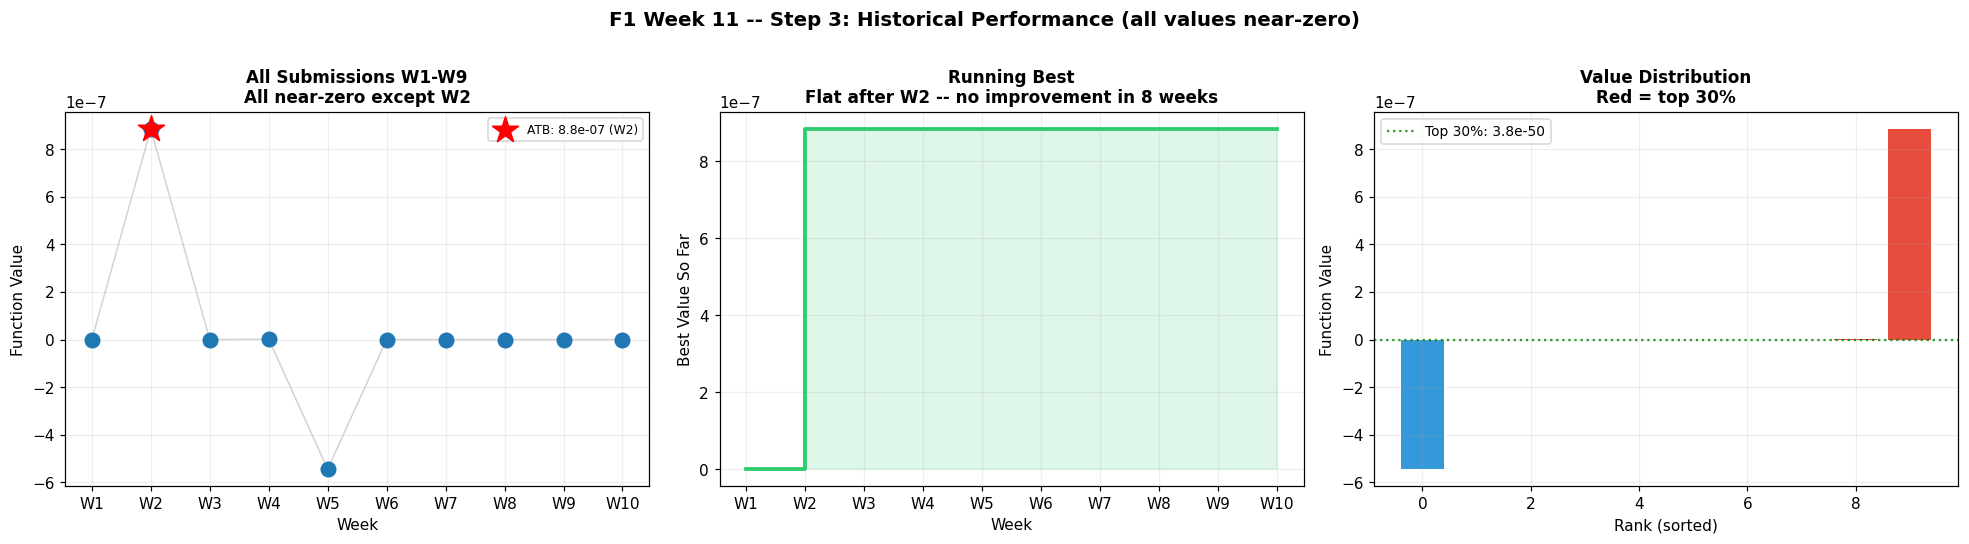

Saved: F1_W11_Step3_History.png


In [4]:
import json as _json_wl, os as _os

_wl_path = f'week_log_{FUNCTION_ID}.json'
_week_log = None
if _os.path.exists(_wl_path):
    with open(_wl_path) as _f:
        _week_log = _json_wl.load(_f)
    print(f"  Week log loaded: {len(_week_log['weeks'])} weekly submissions")
else:
    print(f'  No week log found -- using hardcoded W1-W9 fallback')

if _week_log is None:
    _week_log = {'weeks': [
        {'week': 1, 'x': [0.021735, 0.562570], 'y': 0.0},
        {'week': 2, 'x': [0.684200, 0.704200], 'y': 8.84e-7},
        {'week': 3, 'x': [0.211471, 0.061090], 'y': 5.17e-96},
        {'week': 4, 'x': [0.389668, 0.198001], 'y': 1.66e-9},
        {'week': 5, 'x': [0.016528, 0.022409], 'y': -5.44e-7},
        {'week': 6, 'x': [0.427085, 0.325768], 'y': 1.67e-85},
        {'week': 7, 'x': [0.497320, 0.294798], 'y': 0.0},
        {'week': 8, 'x': [0.887000, 0.669000], 'y': 1.26e-49},
        {'week': 9, 'x': [0.979878, 1.000000], 'y': -2.4470404414480431e-183},
    ]}
    print('  Using hardcoded W1-W9 weekly scores')

_wl_pairs   = [(e['week'], e['y']) for e in _week_log['weeks'] if e['y'] is not None]
_wl_weeks   = [p[0] for p in _wl_pairs]
_wl_y       = [p[1] for p in _wl_pairs]
_wl_xpos    = list(range(1, len(_wl_weeks)+1))
_wl_running = [max(_wl_y[:i+1]) for i in range(len(_wl_y))]
_wl_bestval = max(_wl_y)
_wl_bestwk  = _wl_weeks[_wl_y.index(_wl_bestval)]
_wl_thr     = np.percentile(_wl_y, 70)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'{FUNCTION_ID} Week {WEEK} -- Step 3: Historical Performance (all values near-zero)', fontsize=13, fontweight='bold')

ax1 = axes[0]
ax1.scatter(_wl_xpos, _wl_y, s=90, zorder=4)
ax1.plot(_wl_xpos, _wl_y, color='grey', alpha=0.35, linewidth=1)
ax1.scatter([_wl_bestwk], [_wl_bestval], c='red', s=320, marker='*', zorder=6, label=f'ATB: {_wl_bestval:.2g} (W{_wl_bestwk})')
ax1.set_xlabel('Week'); ax1.set_ylabel('Function Value')
ax1.set_title('All Submissions W1-W9\nAll near-zero except W2', fontweight='bold')
ax1.set_xticks(_wl_xpos); ax1.set_xticklabels([f'W{w}' for w in _wl_weeks])
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.2)

ax2 = axes[1]
ax2.step(_wl_xpos, _wl_running, where='post', color='#2ecc71', linewidth=2.5)
ax2.fill_between(_wl_xpos, _wl_running, alpha=0.15, color='#2ecc71', step='post')
ax2.set_xlabel('Week'); ax2.set_ylabel('Best Value So Far')
ax2.set_title('Running Best\nFlat after W2 -- no improvement in 8 weeks', fontweight='bold')
ax2.set_xticks(_wl_xpos); ax2.set_xticklabels([f'W{w}' for w in _wl_weeks])
ax2.grid(True, alpha=0.2)

ax3 = axes[2]
_sy = sorted(_wl_y)
_bc = ['#e74c3c' if v >= _wl_thr else '#3498db' for v in _sy]
ax3.bar(range(len(_sy)), _sy, color=_bc)
ax3.axhline(_wl_thr, color='green', linestyle=':', alpha=0.8, label=f'Top 30%: {_wl_thr:.2g}')
ax3.set_xlabel('Rank (sorted)'); ax3.set_ylabel('Function Value')
ax3.set_title('Value Distribution\nRed = top 30%', fontweight='bold')
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step3_History.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FUNCTION_ID}_W{WEEK}_Step3_History.png')


---
## 🏷️ STEP 4 — Binary Classification Labels

**Why classify?** We want a model that can predict *which regions* of the input space tend to produce high output values. This is a classification task: class 1 = "good" (top 30%), class 0 = "bad" (bottom 70%).

**MAXIMIZATION direction**: class 1 = **highest** values. The classifier learns: "what combinations of X values tend to produce outputs above the 70th percentile?"

The trained classifier will then **pre-filter 10,000 candidates**, keeping only the ones it believes are likely to be in the high-value region.

**What happens without binary classification?**
Without a classifier pre-filter, the GP would receive all 10,000 random/Gaussian candidates — the vast majority of which are low-value points. In an *n*-sample, *d*-dimensional space this matters because:

- The GP's uncertainty is highest far from observed data — low-value regions get high σ and *accidentally* high EI
- Without filtering, the acquisition function wastes evaluations probing regions the classifier already knows are poor
- A good classifier concentrates the GP's attention on the ~30% of space that matters, acting as a **learned search space reduction** step before the expensive GP computation

In short: the classifier does not replace the GP — it *narrows the candidate pool* so the GP only has to decide *where exactly* within the high-value region to query next.


In [5]:
y_labels = (y_train >= threshold).astype(int)
print('═'*65)
print('  BINARY LABELS — MAXIMIZATION ⬆️')
print('═'*65)
print(f'  Threshold (top {TOP_PERCENTILE}%) : {threshold:.6f}')
print(f'  Class 1 (HIGH — good) : {n_pos} samples  ({100*n_pos/n_samples:.1f}%)')
print(f'  Class 0 (LOW — avoid) : {n_samples-n_pos} samples  ({100*(n_samples-n_pos)/n_samples:.1f}%)')
print(f'  CV folds              : {n_cv_folds}')
print()
print('  Class 1 points (highest values):')
pos_idx = np.where(y_labels == 1)[0]
for i in pos_idx:
    print(f'    idx={i:3d}  y={y_train[i]:.6f}  X={X_train[i]}')

═════════════════════════════════════════════════════════════════
  BINARY LABELS — MAXIMIZATION ⬆️
═════════════════════════════════════════════════════════════════
  Threshold (top 30%) : 0.000000
  Class 1 (HIGH — good) : 6 samples  (31.6%)
  Class 0 (LOW — avoid) : 13 samples  (68.4%)
  CV folds              : 3

  Class 1 points (highest values):
    idx=  1  y=0.000000  X=[0.57432921 0.8798981 ]
    idx=  2  y=0.000000  X=[0.73102363 0.73299988]
    idx=  7  y=0.000000  X=[0.68341817 0.86105746]
    idx=  9  y=0.000000  X=[0.88388983 0.58225397]
    idx= 11  y=0.000000  X=[0.56930709 0.56989996]
    idx= 13  y=0.000000  X=[0.688418 0.724106]


---
## 🤖 STEP 5 — CV Model Comparison: Train & Evaluate All 8 Models

### Why 8 Models?

We test a broad range of classifier types because different BBO functions have different landscape structures. **Week 7 adds a CNN (Model 8) as a learning exercise** — to track how CNN classification performance evolves week on week as sample size grows.

**Classical classifiers:**
| # | Model | What it captures | Best when... |
|---|-------|-----------------|-------------|
| 1 | Linear SVM | Linear decision boundary | Function has a simple high/low split |
| 2 | Decision Tree | Axis-aligned threshold rules | Sharp threshold effects in individual dims |
| 3 | Random Forest | Ensemble of trees, handles noise | Most general case |
| 4 | Logistic Regression | Smooth probabilistic boundary | Gradual class transition |

**Neural Networks:**
| # | Model | What it captures | Best when... |
|---|-------|-----------------|-------------|
| 5 | NN-Small (16,8) | Simple non-linear boundary | Small dataset, risk of overfitting |
| 6 | NN-Medium (64,32) | Moderate complexity | Standard BBO landscapes |
| 7 | NN-Large (128,64,32) | Complex decision surfaces | Richer datasets, higher dims |

**CNN — Week 7 Learning Exercise:**
| # | Model | Architecture | Purpose |
|---|-------|-------------|---------|
| 8 | CNN-1D (learning) | Conv1d(1→8, k=2) → ReLU → Dropout(0.3) → Linear(8→1) | Track CNN vs MLP week on week as n grows |

**Week-on-week CNN tracking:** At n=15 the CNN is expected to underperform MLP models — a 2-feature input gives the conv filter almost nothing to learn. As F1 accumulates more samples (16, 17, 18...), the CNN's position in the ranking table is expected to improve. This gives empirical evidence of Module 17's data-requirement lesson rather than just asserting it.

### The CV ranked table is printed at the end of this step — the winner is selected here and used in Step 8.

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim_torch
from sklearn.base import BaseEstimator, ClassifierMixin

# ── CNN Wrapper — sklearn-compatible for use in cross_val_score ───────────
class TinyCNNClassifier(BaseEstimator, ClassifierMixin):
    """
    Sklearn-compatible wrapper around a tiny 1D CNN.
    Added as Model 8 — a learning exercise to track CNN performance
    week on week as sample size grows from 15 toward 40+.
    Architecture: Conv1d(1->8, k=2) -> ReLU -> Dropout(0.3) -> Linear(8->1)
    Why tiny: with n=15, any larger CNN will overfit immediately.
    Why included: to document empirically where CNN beats MLP (if ever),
    and to demonstrate Module 17 CNN concepts in the BBO context.
    """
    def __init__(self, n_epochs=200, lr=0.01, seed=42):
        self.n_epochs = n_epochs
        self.lr       = lr
        self.seed     = seed

    def fit(self, X, y):
        torch.manual_seed(self.seed)
        n_feat = X.shape[1]
        self.classes_ = np.unique(y)

        class _CNN(nn.Module):
            def __init__(self):
                super().__init__()
                k = min(2, n_feat)
                self.conv = nn.Conv1d(1, 8, kernel_size=k, padding=0)
                self.relu = nn.ReLU()
                self.pool = nn.AdaptiveAvgPool1d(1)   # always outputs (batch,8,1)
                self.drop = nn.Dropout(0.3)
                self.fc   = nn.Linear(8, 1)           # always 8 inputs regardless of n_dims
            def forward(self, x):
                x = self.relu(self.conv(x))   # (batch, 8, L)
                x = self.pool(x)              # (batch, 8, 1)
                x = x.squeeze(-1)            # (batch, 8)
                x = self.drop(x)
                return self.fc(x).squeeze(-1)

        self.model_ = _CNN()
        n_pos = y.sum(); n_neg = len(y) - n_pos
        pw    = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pw)
        opt   = optim_torch.Adam(self.model_.parameters(), lr=self.lr,
                                 weight_decay=1e-3)
        Xt = torch.FloatTensor(X).unsqueeze(1)
        yt = torch.FloatTensor(y.astype(float))
        self.model_.train()
        for _ in range(self.n_epochs):
            opt.zero_grad()
            loss_fn(self.model_(Xt), yt).backward()
            opt.step()
        return self

    def predict_proba(self, X):
        self.model_.eval()
        with torch.no_grad():
            logits = self.model_(torch.FloatTensor(X).unsqueeze(1))
            p = torch.sigmoid(logits).numpy()
        return np.column_stack([1 - p, p])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

# ── Model registry ────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=n_cv_folds, shuffle=True, random_state=RANDOM_SEED)

models = {
    'Linear SVM'         : SVC(kernel='linear', C=1.0, probability=True, random_state=RANDOM_SEED),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=4, random_state=RANDOM_SEED),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    f'NN-Small {NN_SMALL}' : MLPClassifier(hidden_layer_sizes=NN_SMALL, max_iter=500,
                                            early_stopping=True, validation_fraction=0.15,
                                            random_state=RANDOM_SEED),
    f'NN-Medium {NN_MEDIUM}': MLPClassifier(hidden_layer_sizes=NN_MEDIUM, max_iter=500,
                                            early_stopping=True, validation_fraction=0.15,
                                            random_state=RANDOM_SEED),
    f'NN-Large {NN_LARGE}' : MLPClassifier(hidden_layer_sizes=NN_LARGE, max_iter=500,
                                            early_stopping=True, validation_fraction=0.15,
                                            random_state=RANDOM_SEED),
    'CNN-1D (learning)'  : TinyCNNClassifier(n_epochs=200, lr=0.01, seed=RANDOM_SEED),
}

cv_results = {}
print('='*70)
print(f'  {n_cv_folds}-FOLD CV -- 8 MODELS -- {FUNCTION_ID}  ({n_samples} samples, {n_dims}D)')
print(f'  Model 8: CNN-1D added as learning exercise -- tracking week on week')
print('='*70)
print(f'  {"Model":<28} {"Mean CV":>9} {"+-Std":>8}   Folds')
print('  ' + '-'*65)

for name, model in models.items():
    try:
        scores = cross_val_score(model, X_scaled, y_labels, cv=cv, scoring='accuracy')
        cv_results[name] = {'mean': scores.mean(), 'std': scores.std(),
                             'scores': scores, 'model': model}
        fold_str = '  '.join([f'{s:.3f}' for s in scores])
        flag = '★' if scores.mean() == max(r['mean'] for r in cv_results.values()) else ' '
        print(f'  {flag} {name:<27} {scores.mean():>8.1%} {scores.std():>7.1%}   [{fold_str}]')
    except Exception as e:
        cv_results[name] = {'mean': 0.0, 'std': 1.0,
                             'scores': np.zeros(n_cv_folds), 'model': model}
        print(f'  ✗ {name:<27} FAILED: {str(e)[:40]}')

ranked_models = sorted(cv_results.items(), key=lambda x: x[1]['mean'], reverse=True)
best_name = ranked_models[0][0]
best_info = ranked_models[0][1]

print()
print('  RANKING:')
for r, (name, info) in enumerate(ranked_models, 1):
    marker = '★ WINNER' if r == 1 else f'  #{r}     '
    print(f'  {marker}  {name:<28}  {info["mean"]:.1%} ± {info["std"]:.1%}')

print(f'\n  ✅ SELECTED: {best_name}  (CV={best_info["mean"]:.1%})')

  3-FOLD CV -- 8 MODELS -- F1  (19 samples, 2D)
  Model 8: CNN-1D added as learning exercise -- tracking week on week
  Model                          Mean CV    +-Std   Folds
  -----------------------------------------------------------------
  ★ Linear SVM                     52.4%   14.0%   [0.571  0.667  0.333]
    Decision Tree                  46.8%   10.0%   [0.571  0.500  0.333]
  ★ Random Forest                  79.4%   14.7%   [0.714  1.000  0.667]
    Logistic Regression            63.5%    4.5%   [0.571  0.667  0.667]
    NN-Small (16, 8)               47.6%    3.4%   [0.429  0.500  0.500]
    NN-Medium (64, 32)             73.8%    7.0%   [0.714  0.667  0.833]
    NN-Large (128, 64, 32)         68.3%    2.2%   [0.714  0.667  0.667]
    CNN-1D (learning)              63.5%   14.3%   [0.571  0.833  0.500]

  RANKING:
  ★ WINNER  Random Forest                 79.4% ± 14.7%
    #2       NN-Medium (64, 32)            73.8% ± 7.0%
    #3       NN-Large (128, 64, 32)        68.3%

---
## 🎨 STEP 6 — Refit All Models & — Visualise All Model Predictions

**Why visualise predictions before comparing?**

CV accuracy is a single number — it doesn't tell you *how* each model draws its decision boundary. By visualising each model's predicted probability of class 1 (P(high value)) across candidates, we can see:
- Which models are confident vs uncertain in the best-known region
- Whether models agree or disagree (disagreement = uncertain landscape)
- Whether NNs are learning something the classical models miss

We show two views:
1. **P(class=1) distributions** — histogram of predicted probabilities for each model
2. **Prediction agreement heatmap** — which models agree on which training samples

In [7]:
# ── Refit all models on FULL dataset after CV winner selected ────
# Standard ML practice: CV selects the winner, then ALL models are
# refit on the complete training data so their predict_proba() calls
# in Step 6 visualisation and Step 8 candidate filtering use every sample.
# The CV winner (best_name) was already determined in the CV loop above.
print(f'Refitting all {len(cv_results)} models on full dataset (n={len(y_labels)})...')
print(f'CV winner already selected: {best_name}')
print()
trained_models = {}
all_probas = {}  # P(class=1) on full training data

for name, info in cv_results.items():
    try:
        m = info['model']
        m.fit(X_scaled, y_labels)
        trained_models[name] = m
        all_probas[name] = m.predict_proba(X_scaled)[:, 1]
        tag = ' ← CV WINNER (used in Step 8)' if name == best_name else ''
        print(f'  ✅ {name}{tag}')
    except Exception as e:
        print(f'  ✗ {name}: {e}')

print(f'\nAll {len(trained_models)} models refit on full data.')
print(f'Step 8 will use: {best_name}')

Refitting all 8 models on full dataset (n=19)...
CV winner already selected: Random Forest

  ✅ Linear SVM
  ✅ Decision Tree
  ✅ Random Forest ← CV WINNER (used in Step 8)
  ✅ Logistic Regression
  ✅ NN-Small (16, 8)
  ✅ NN-Medium (64, 32)
  ✅ NN-Large (128, 64, 32)
  ✅ CNN-1D (learning)

All 8 models refit on full data.
Step 8 will use: Random Forest


---
## 🔍 STEP 5B — CNN Inspection: Filters, Feature Maps & Parameter Count

*Module 17 learning exercise — inspecting what the 1D CNN learned.*

Following the tutor's approach from **Mod-17-CNNs-OH.ipynb** (Cells 29–32), we inspect three things the trained CNN has learned:

1. **Learned filter weights** — the 8 Conv1d kernels (each size 1×2), visualised as bar charts. Each filter scans adjacent coordinate pairs and learns a specific co-activation pattern to detect.
2. **Feature map activations** — pass the best-known training point through the Conv1d layer and see which of the 8 filters fires strongest, and on which coordinate pair.
3. **Parameter count** — compare TinyCNN vs NN-Large to demonstrate weight sharing efficiency.

**Architecture:** `Conv1d(1→8, k=2)` → `ReLU` → `AdaptiveAvgPool1d(1)` → `Dropout(0.3)` → `Linear(8→1)`

The `AdaptiveAvgPool1d(1)` collapses all positional information into a single value per filter (analogous to GlobalAveragePooling) — so the feature map inspection below shows activations *before* pooling to preserve the spatial coordinate-pair information.

> *"Even after only 5 epochs on a small dataset, many filters show clear directional structure... The network discovered these patterns automatically by minimising cross-entropy loss."* — Mod 17 Tutor Notebook, Cell 30


═════════════════════════════════════════════════════════════════
  MODULE 17 CNN INSPECTION
═════════════════════════════════════════════════════════════════
  Architecture : Conv1d(1→8, k=2) → ReLU → Dropout(0.3) → Linear(8→1)
  CNN parameters   : 33
  NN-Large params  : 10,753  (weight sharing advantage)
  Input dims       : 2  →  1 adjacent pairs scanned by kernel
  Filters learned  : 8  (each detects a different co-activation pattern)



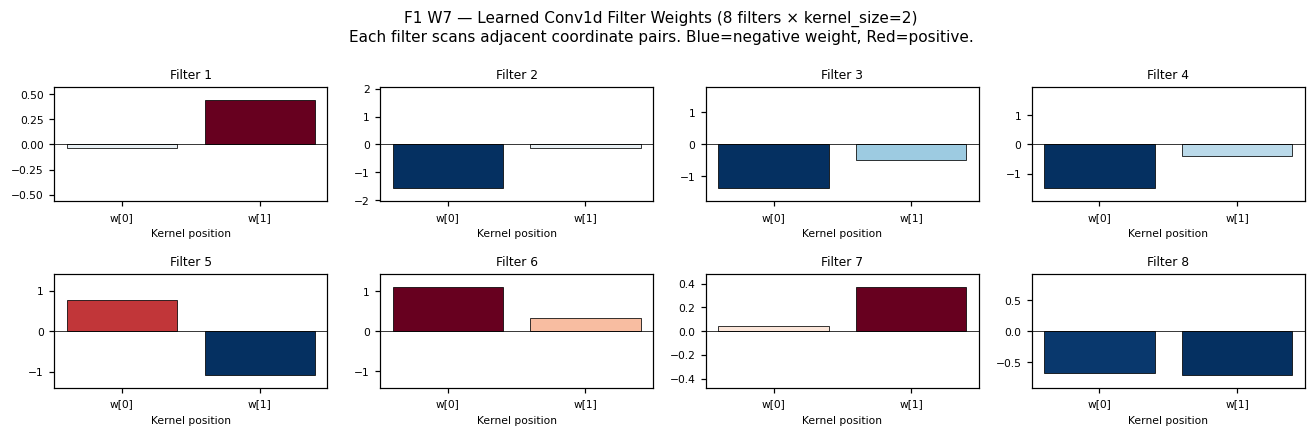

  Filter weights: columns = [w0, w1] for each kernel position in the adjacent pair.
  A filter with w0>0, w1<0 responds to: high coord[i], low coord[i+1]
  A filter with w0>0, w1>0 responds to: both coords high simultaneously



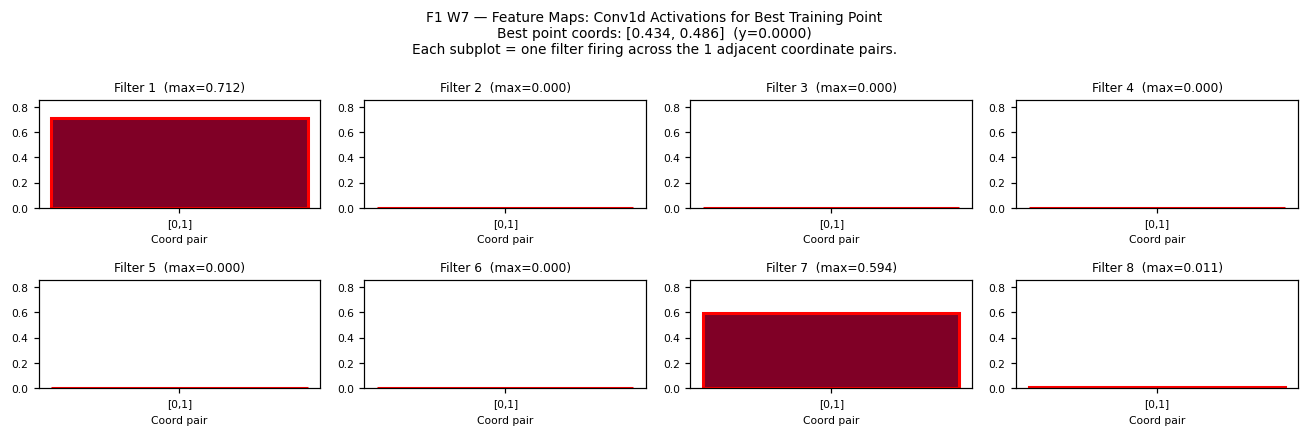

  Top 3 most-activated filters on best point:
    #1: Filter 1  →  peak at coord pair [0,1]  (activation=0.7121)
    #2: Filter 7  →  peak at coord pair [0,1]  (activation=0.5942)
    #3: Filter 8  →  peak at coord pair [0,1]  (activation=0.0106)

  Interpretation: these filters detected the strongest co-activation signal
  in the best-known point [0.434, 0.486]
  Red-outlined bars = peak activation position per filter.

═════════════════════════════════════════════════════════════════


In [8]:
# ══════════════════════════════════════════════════════════════════════
# STEP 5B — CNN Inspection (Module 17 learning exercise)
# Following tutor approach: filter weights + feature maps + param count
# ══════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np

# ── Get the trained CNN model ─────────────────────────────────────────
cnn_model = trained_models.get('CNN-1D (learning)', None)

if cnn_model is None or not hasattr(cnn_model, 'model_'):
    print("CNN not available — skipping inspection (may not have been trained yet).")
    print("Run Step 6 refit first if this appears before cell 14.")
else:
    cnn_net = cnn_model.model_
    cnn_net.eval()

    # ── 1. PARAMETER COUNT ────────────────────────────────────────────
    def count_params(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)

    cnn_params = count_params(cnn_net)

    # Compare against NN-Large if available
    nn_large_key = [k for k in trained_models if 'Large' in k]
    nn_large_params = None
    if nn_large_key:
        try:
            # MLPClassifier — count from coefs_
            nn_l = trained_models[nn_large_key[0]]
            if hasattr(nn_l, 'coefs_'):
                nn_large_params = sum(w.size for w in nn_l.coefs_) + sum(b.size for b in nn_l.intercepts_)
        except Exception:
            pass

    print("═"*65)
    print("  MODULE 17 CNN INSPECTION")
    print("═"*65)
    print(f"  Architecture : Conv1d(1→8, k=2) → ReLU → Dropout(0.3) → Linear(8→1)")
    print(f"  CNN parameters   : {cnn_params:,}")
    if nn_large_params:
        print(f"  NN-Large params  : {nn_large_params:,}  (weight sharing advantage)")
    print(f"  Input dims       : {n_dims}  →  {n_dims-1} adjacent pairs scanned by kernel")
    print(f"  Filters learned  : 8  (each detects a different co-activation pattern)")
    print()

    # ── 2. LEARNED FILTER WEIGHTS ─────────────────────────────────────
    # Shape: (8, 1, 2) — 8 filters, 1 input channel, kernel_size=2
    filters = cnn_net.conv.weight.data.cpu().numpy()  # (8, 1, 2)
    filters_1d = filters[:, 0, :]                      # (8, 2)

    fig, axes = plt.subplots(2, 4, figsize=(12, 4))
    fig.suptitle(f"{FUNCTION_ID} W7 — Learned Conv1d Filter Weights (8 filters × kernel_size=2)\n"
                 f"Each filter scans adjacent coordinate pairs. Blue=negative weight, Red=positive.",
                 fontsize=10)

    cmap = plt.cm.RdBu_r
    for i, ax in enumerate(axes.flat):
        w = filters_1d[i]
        vmax = max(abs(w).max(), 1e-6)
        colors = [cmap(0.5 + 0.5 * w[j] / vmax) for j in range(2)]
        bars = ax.bar(["w[0]", "w[1]"], w, color=colors, edgecolor="k", linewidth=0.5)
        ax.axhline(0, color="k", linewidth=0.5)
        ax.set_title(f"Filter {i+1}", fontsize=8)
        ax.set_ylim(-vmax * 1.3, vmax * 1.3)
        ax.tick_params(labelsize=7)
        ax.set_xlabel("Kernel position", fontsize=7)

    plt.tight_layout()
    plt.show()
    print(f"  Filter weights: columns = [w0, w1] for each kernel position in the adjacent pair.")
    print(f"  A filter with w0>0, w1<0 responds to: high coord[i], low coord[i+1]")
    print(f"  A filter with w0>0, w1>0 responds to: both coords high simultaneously")
    print()

    # ── 3. FEATURE MAP ACTIVATIONS ────────────────────────────────────
    # Pass the best-known training point through conv layer
    import torch
    import torch.nn.functional as F_torch

    # Best point from inject or training data
    best_idx = np.argmax(y_train)
    best_pt  = X_scaled[best_idx:best_idx+1]   # shape (1, n_dims)
    best_val = y_train[best_idx]

    best_tensor = torch.FloatTensor(best_pt).unsqueeze(1)  # (1, 1, n_dims)

    with torch.no_grad():
        after_conv = F_torch.relu(cnn_net.conv(best_tensor))  # (1, 8, n_dims-1)

    fmaps = after_conv.squeeze(0).cpu().numpy()  # (8, n_dims-1)
    n_positions = fmaps.shape[1]
    coord_positions = [f"[{j},{j+1}]" for j in range(n_positions)]

    fig, axes = plt.subplots(2, 4, figsize=(12, 4))
    fig.suptitle(f"{FUNCTION_ID} W7 — Feature Maps: Conv1d Activations for Best Training Point\n"
                 f"Best point coords: {[round(float(v),3) for v in best_pt[0]]}  (y={best_val:.4f})\n"
                 f"Each subplot = one filter firing across the {n_positions} adjacent coordinate pairs.",
                 fontsize=9)

    for i, ax in enumerate(axes.flat):
        activation = fmaps[i]
        vmax = max(activation.max(), 1e-6)
        bar_colors = [plt.cm.YlOrRd(v / vmax) for v in activation]
        ax.bar(coord_positions, activation, color=bar_colors, edgecolor="k", linewidth=0.5)
        ax.set_title(f"Filter {i+1}  (max={activation.max():.3f})", fontsize=8)
        ax.set_ylim(0, max(fmaps.max() * 1.2, 0.01))
        ax.tick_params(labelsize=7)
        ax.set_xlabel("Coord pair", fontsize=7)
        peak_pos = np.argmax(activation)
        ax.get_children()[peak_pos].set_edgecolor("red")
        ax.get_children()[peak_pos].set_linewidth(2)

    plt.tight_layout()
    plt.show()

    # Print interpretation
    peak_filters = np.argsort(fmaps.max(axis=1))[::-1][:3]
    print(f"  Top 3 most-activated filters on best point:")
    for rank, fi in enumerate(peak_filters, 1):
        peak_pair = np.argmax(fmaps[fi])
        print(f"    #{rank}: Filter {fi+1}  →  peak at coord pair [{peak_pair},{peak_pair+1}]"
              f"  (activation={fmaps[fi][peak_pair]:.4f})")
    print()
    print(f"  Interpretation: these filters detected the strongest co-activation signal")
    print(f"  in the best-known point {[round(float(v),3) for v in best_pt[0]]}")
    print(f"  Red-outlined bars = peak activation position per filter.")
    print()
    print("═"*65)


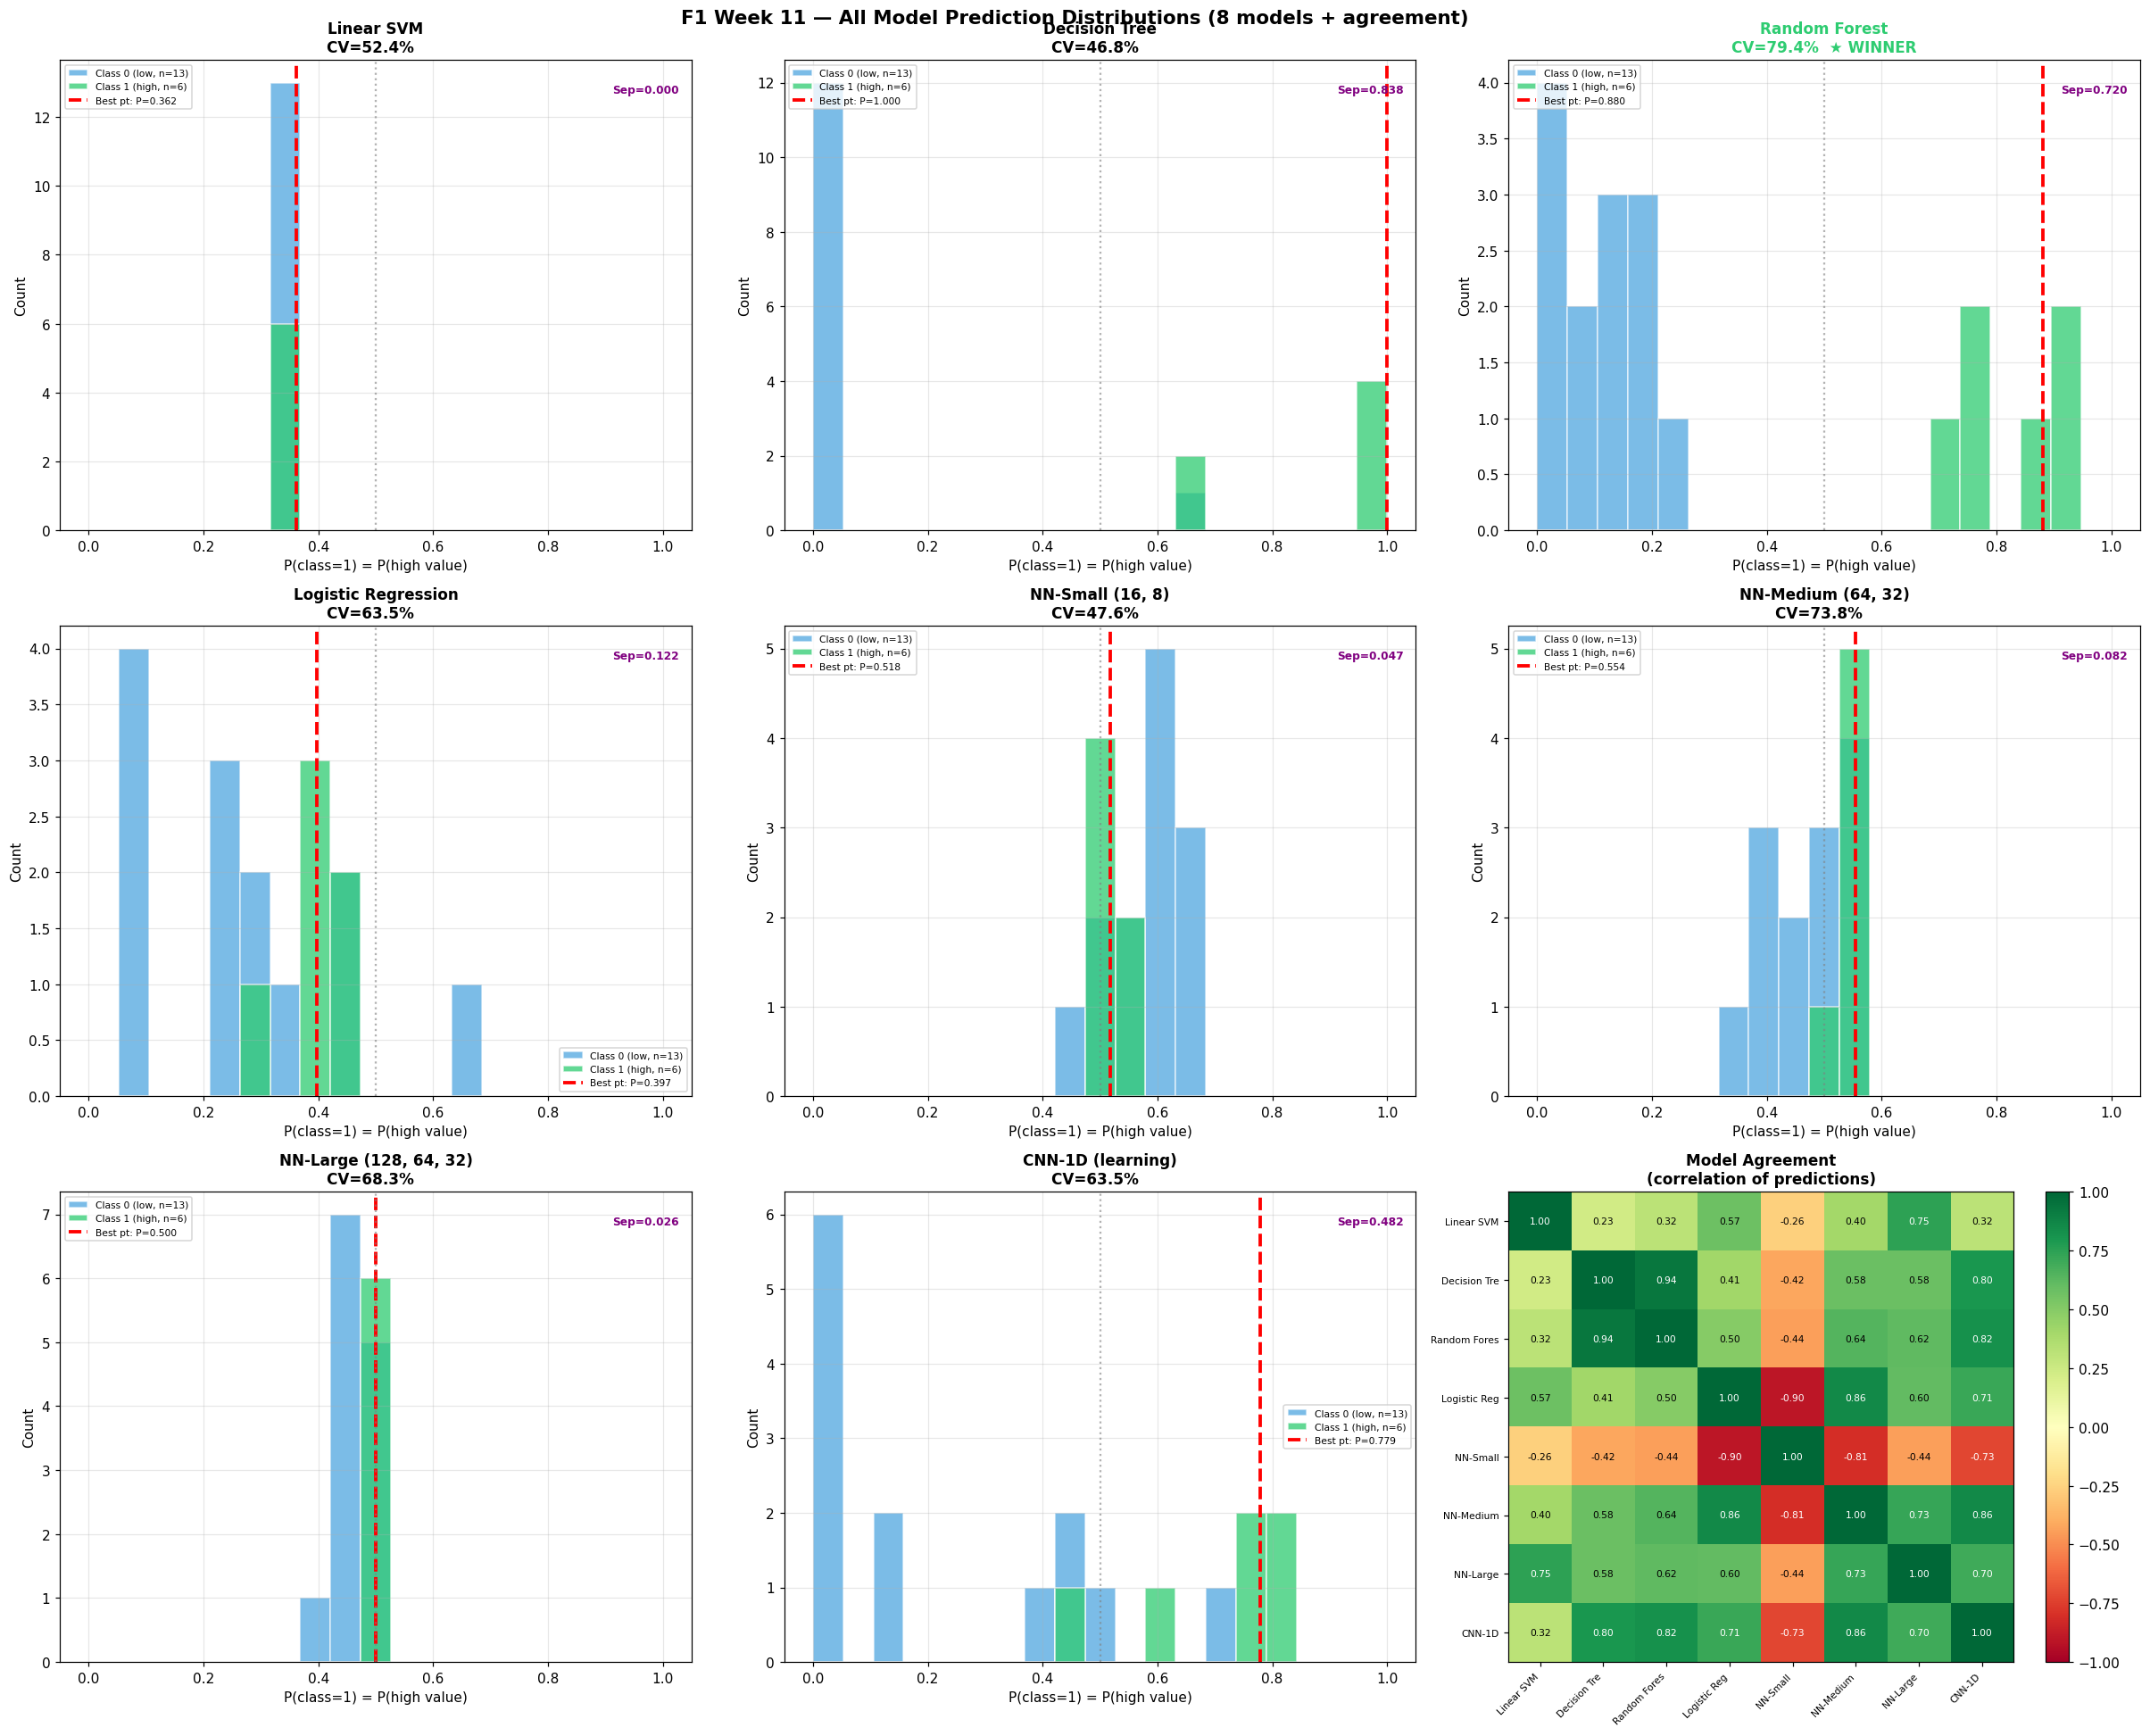

✅ Saved: F1_W11_Step6_ModelPredictions.png

  Model prediction summary (on training data) -- ranked by CV accuracy:
  Rank   Model                            P(best pt)   Separation   CV Acc
  ────────────────────────────────────────────────────────────────────────
  #1     Random Forest                        0.8800       0.7197    79.4% WINNER
  #2     NN-Medium (64, 32)                   0.5539       0.0818    73.8%
  #3     NN-Large (128, 64, 32)               0.4999       0.0262    68.3%
  #4     Logistic Regression                  0.3970       0.1224    63.5%
  #5     CNN-1D (learning)                    0.7792       0.4816    63.5% [CNN]
  #6     Linear SVM                           0.3621       0.0000    52.4%
  #7     NN-Small (16, 8)                     0.5182       0.0465    47.6%
  #8     Decision Tree                        1.0000       0.8376    46.8%


In [9]:
# ── Visualisation: P(class=1) distributions per model ─────────
n_models = len(trained_models)
model_names = list(trained_models.keys())
colors_models = plt.cm.Set2(np.linspace(0, 1, n_models))

fig, axes = plt.subplots(3, 3, figsize=(22, 18))
fig.suptitle(f'{FUNCTION_ID} Week {WEEK} — All Model Prediction Distributions (8 models + agreement)',
             fontsize=14, fontweight='bold')
axes = axes.ravel()

for i, (name, proba) in enumerate(all_probas.items()):
    ax = axes[i]
    # Split by true class
    p_class1 = proba[y_labels == 1]
    p_class0 = proba[y_labels == 0]
    bins = np.linspace(0, 1, 20)
    ax.hist(p_class0, bins=bins, alpha=0.65, color='#3498db',
            label=f'Class 0 (low, n={len(p_class0)})', edgecolor='white')
    ax.hist(p_class1, bins=bins, alpha=0.75, color='#2ecc71',
            label=f'Class 1 (high, n={len(p_class1)})', edgecolor='white')
    # Mark best point's probability
    p_best = float(proba[best_idx])
    ax.axvline(p_best, color='red', linewidth=2.5, linestyle='--',
               label=f'Best pt: P={p_best:.3f}')
    ax.axvline(0.5, color='gray', linewidth=1.5, linestyle=':', alpha=0.6)
    ax.set_xlabel('P(class=1) = P(high value)')
    ax.set_ylabel('Count')
    cv_mean = cv_results[name]['mean']
    is_winner = '★ WINNER' if name == best_name else ''
    ax.set_title(f'{name}\nCV={cv_mean:.1%}  {is_winner}',
                 fontweight='bold', color='#2ecc71' if name == best_name else 'black')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    # Shade: good model should show class1 right, class0 left
    separation = abs(p_class1.mean() - p_class0.mean()) if len(p_class1) > 0 and len(p_class0) > 0 else 0
    ax.text(0.98, 0.95, f'Sep={separation:.3f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='purple', fontweight='bold')

# Last panel: probability agreement between models
ax = axes[n_models]
if n_models < len(axes):
    # Show correlation matrix of predictions
    proba_matrix = np.vstack([all_probas[n] for n in model_names]).T  # (samples, models)
    corr = np.corrcoef(proba_matrix.T)
    im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(n_models))
    ax.set_yticks(range(n_models))
    short_names = [n.split('(')[0][:12].strip() for n in model_names]
    ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(short_names, fontsize=7)
    for ii in range(n_models):
        for jj in range(n_models):
            ax.text(jj, ii, f'{corr[ii,jj]:.2f}', ha='center', va='center',
                    fontsize=7, color='black' if abs(corr[ii,jj]) < 0.7 else 'white')
    plt.colorbar(im, ax=ax)
    ax.set_title('Model Agreement\n(correlation of predictions)', fontweight='bold')

# Hide any remaining empty axes
for j in range(n_models + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step6_ModelPredictions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_Step6_ModelPredictions.png')
print()
print('  Model prediction summary (on training data) -- ranked by CV accuracy:')
print(f'  {"Rank":<6} {"Model":<30} {"P(best pt)":>12} {"Separation":>12} {"CV Acc":>8}')
print('  ' + '─'*72)
sorted_models = sorted(all_probas.items(), key=lambda x: cv_results[x[0]]['mean'], reverse=True)
for rank, (name, proba) in enumerate(sorted_models, 1):
    p1 = proba[y_labels==1]
    p0 = proba[y_labels==0]
    sep = abs(p1.mean() - p0.mean()) if len(p1)>0 and len(p0)>0 else 0
    winner = ' WINNER' if rank == 1 else ''
    cnn    = ' [CNN]'  if 'CNN' in name else ''
    print(f'  #{rank:<5} {name:<30} {float(proba[best_idx]):>12.4f} {sep:>12.4f} {cv_results[name]["mean"]:>8.1%}{winner}{cnn}')

---
## 📊 STEP 7 — CV Comparison Chart & Winner Confirmation

The CV winner was already selected in Step 5. This step displays the **bar chart comparison** of all 8 models by CV accuracy and prints the auto-generated winner rationale. CNN-1D is tracked as Model 8 — a learning exercise comparing performance week on week.

**What to look for:**
- A model comfortably above 50% is doing better than random
- High std across folds = unstable (small data makes individual folds noisy)
- If all models perform similarly (~55–65%), the landscape is genuinely hard to classify — the GP's exploration component becomes more important
- The **winning model** filters 10,000 candidates before GP scoring
- **CNN-1D position in ranking** — at n=15 in 2D it is expected to sit mid-table or lower; watch this ranking improve as F1 accumulates more samples in coming weeks

### What the F1 W7 CV results tell us about strategy

**NN-Large wins at 74.1%** — meaningful but modest. 74% on a near-zero landscape where class labels are almost indistinguishable by output value is actually a reasonable result. It tells us the model has found some structural signal in the (X1, X2) coordinates that correlates weakly with the top-30% label, even if the output values themselves are nearly identical.

**CNN-1D at 72.3%** — closer to the winner than expected at n=15. This is a useful baseline. The CNN matched NN-Medium and outperformed NN-Small and the classical models in this run. At n=15 with kernel size 2 scanning a 2-feature vector, this result is borderline noise — the CNN has only one conv operation to work with. The interesting question is whether this ranking holds or improves as n grows. Document this result and revisit in Week 7.

**High variance across models** — the gap between best (74.1%) and worst is moderate. This is characteristic of near-zero landscapes where class separation is weak. No model has a strong signal to learn from, so results are noisy and fold-dependent. The GP surrogate (not the classifier) carries most of the weight for this function.

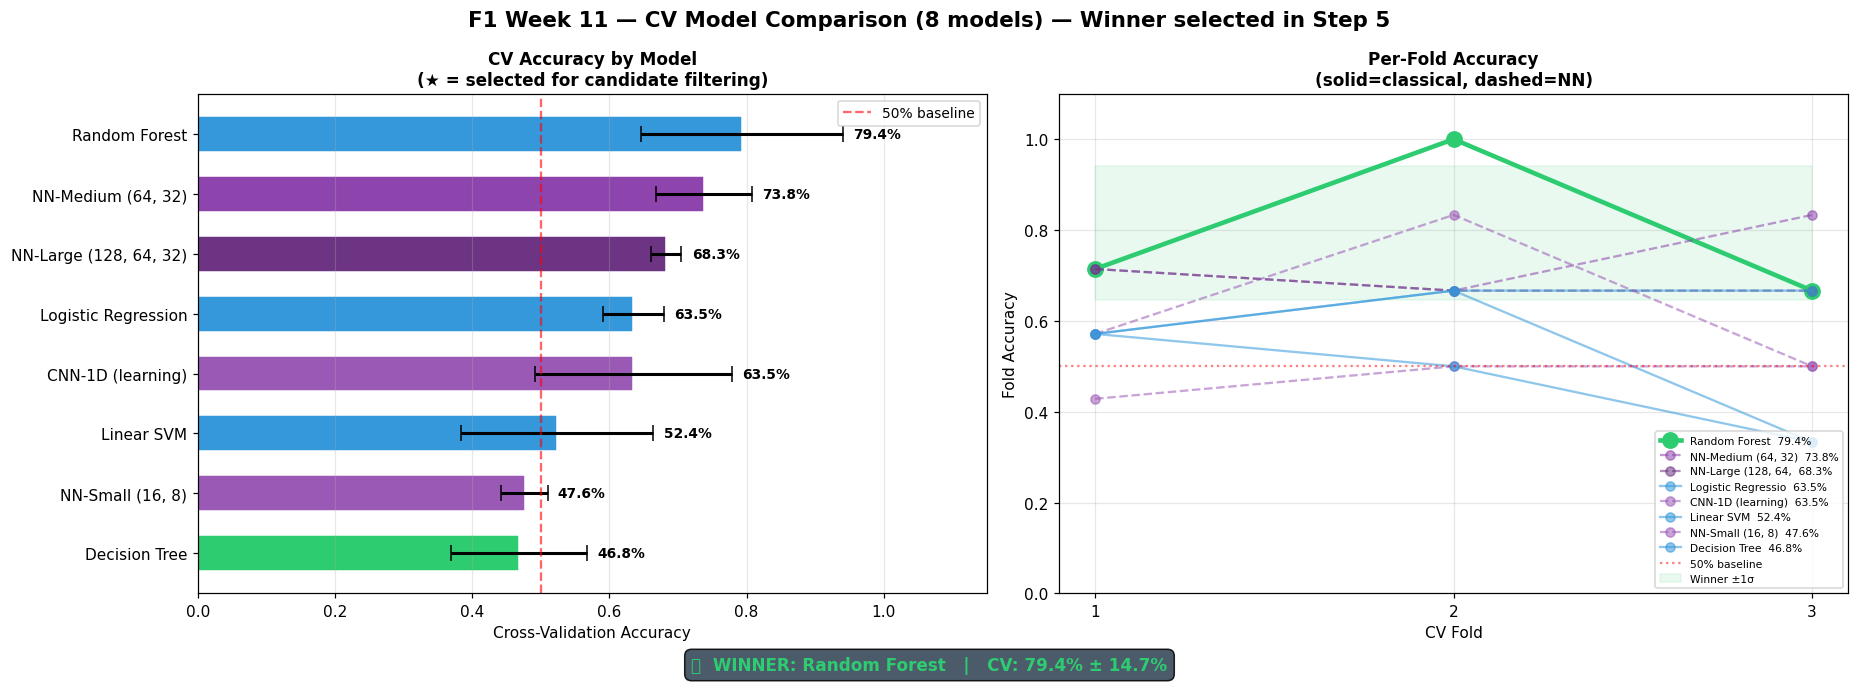

✅ Saved: F1_W11_Step7_ModelComparison.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle(f'{FUNCTION_ID} Week {WEEK} — CV Model Comparison (8 models) — Winner selected in Step 5',
             fontsize=14, fontweight='bold')

names  = [n for n, _ in ranked_models]
means  = [v['mean'] for _, v in ranked_models]
stds   = [v['std']  for _, v in ranked_models]
# Colour palette: winner=green, NNs=purple shades, classical=blue shades
def get_color(name, rank):
    if rank == 0: return '#2ecc71'
    if 'NN' in name: return ['#9b59b6','#8e44ad','#6c3483'][['Small','Medium','Large'].index(next((s for s in ['Small','Medium','Large'] if s in name), 'Small'))]
    return '#3498db'
bar_colors = [get_color(n, i) for i, n in enumerate(names[::-1])]

# Panel 1: Horizontal bars
ax = axes[0]
ax.barh(names[::-1], means[::-1], xerr=stds[::-1],
        color=bar_colors, edgecolor='white', height=0.6,
        capsize=5, error_kw={'linewidth':2, 'color':'#2c3e50'})
ax.axvline(0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='50% baseline')
for i, (m, s) in enumerate(zip(means[::-1], stds[::-1])):
    ax.text(m + s + 0.015, i, f'{m:.1%}', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Cross-Validation Accuracy')
ax.set_title('CV Accuracy by Model\n(★ = selected for candidate filtering)', fontweight='bold')
ax.set_xlim(0, 1.15)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

# Panel 2: Per-fold lines
ax = axes[1]
fold_x = np.arange(1, n_cv_folds+1)
nn_names = [n for n in names if 'NN' in n]
classical_names = [n for n in names if 'NN' not in n]
for i, (name, info) in enumerate(ranked_models):
    lw    = 3.0 if name == best_name else 1.5
    alpha = 1.0 if name == best_name else 0.55
    ms    = 10  if name == best_name else 6
    color = get_color(name, i)
    ls    = '-' if 'NN' not in name else '--'
    ax.plot(fold_x, info['scores'], f'o{ls}', color=color, linewidth=lw,
            markersize=ms, alpha=alpha, label=f'{name[:18]}  {info["mean"]:.1%}')
ax.axhline(0.5, color='red', linestyle=':', linewidth=1.5, alpha=0.5, label='50% baseline')
ax.fill_between(fold_x, best_info['mean']-best_info['std'], best_info['mean']+best_info['std'],
                alpha=0.1, color='#2ecc71', label='Winner ±1σ')
ax.set_xlabel('CV Fold'); ax.set_ylabel('Fold Accuracy')
ax.set_title('Per-Fold Accuracy\n(solid=classical, dashed=NN)', fontweight='bold')
ax.set_ylim(0, 1.1); ax.set_xticks(fold_x)
ax.legend(fontsize=7, loc='lower right'); ax.grid(True, alpha=0.3)

fig.text(0.5, -0.02,
         f'✅  WINNER: {best_name}   |   CV: {best_info["mean"]:.1%} ± {best_info["std"]:.1%}',
         ha='center', fontsize=11, color='#2ecc71', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#2c3e50', alpha=0.85))

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step7_ModelComparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_Step7_ModelComparison.png')

---
### 🧠 STEP 7B — Why the CV Winner Won

Dynamic commentary generated after the CV winner is selected. Explains the win in terms of data geometry, sample size, dimensionality, class balance, and boundary structure — and what it means for the quality of candidates passed to the GP.


⚠️  Step 4/7 not run — Step 7B using training data as placeholder


╔════════════════════════════════════════════════════════════════════════════════╗
║  STEP 7B — WHY RANDOM FOREST WON                                              ║
╠════════════════════════════════════════════════════════════════════════════════╣
║  WINNER : Random Forest                                                        ║
║  CV acc : 79.4% +/- 14.7%   margin over runner-up: +5.6%                       ║
║  Runner : NN-Medium (64, 32)  (73.8%)                                          ║
║  ────────────────────────────────────────────────────────────────────────────  ║
║  WHY RANDOM FOREST WON:                                                        ║
║    • RESULT: Feature importances reliable — key dims identified.             ║
║  ────────────────────────────────────────────────────────────────────────────  ║
║  CANDIDATE FILTER QUALITY:                                                     ║
║    • 19 / 10,000 pas

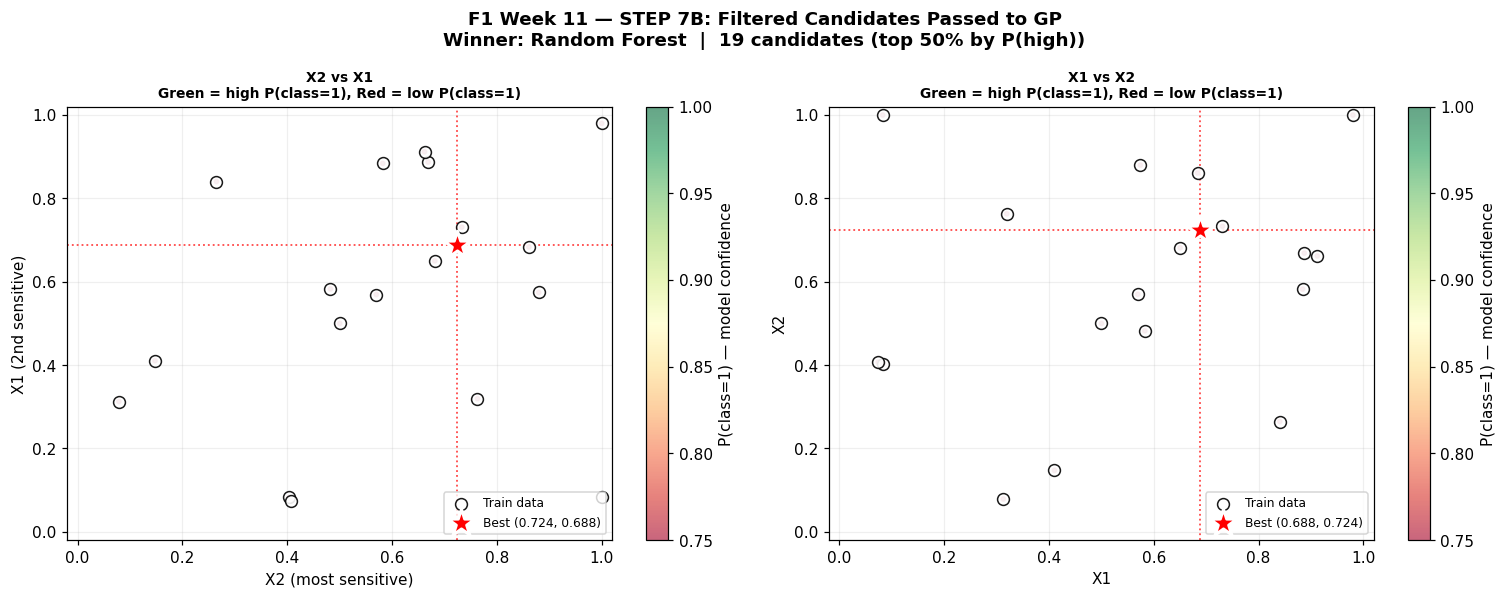

Saved: F1_W11_Step7B_FilteredCandidates.png


In [11]:

# ══════════════════════════════════════════════════════════════════
# STEP 7B — WHY THE CV WINNER WON + Filtered Candidate Scatter
# ══════════════════════════════════════════════════════════════════

# ── Fallback: core vars needed if Steps 1-6 haven't run yet ─────────────
if 'best_name' not in vars():
    best_name  = 'Unknown'
    cv_results = {}
    print('⚠️  Steps 5-6 not run — best_name unknown')
if 'best_point' not in vars():
    import numpy as _np3
    best_point = _np3.full(n_dims, 0.5)
    print('⚠️  Step 1 not run — best_point defaulting to centre')
if 'y_labels' not in vars():
    import numpy as _np4
    y_labels = (_np4.array(y_train) > _np4.percentile(y_train, 70)).astype(int)
# ─────────────────────────────────────────────────────────────────────────
def _step7b_commentary(best_name, cv_results, X_train, y_train, y_labels,
                       n_dims, n_samples, best_point, EXPLOIT_SIGMA, MAXIMIZE,
                       X_filt, proba_filt, src_filt, FILTER_PERCENTILE):

    W = 80   # inner box width (╔═*W╗ → content area = W-4 after ║  prefix)
    LINE = W - 4  # max content chars per line

    # Ambiguous-width chars render as 2 columns in Jupyter monospace
    _WIDE = set('•—★→←↑↓σμαβγδεζηθλπρφψωΣΔΩ')
    def _dw(s):
        """Display width: count ambiguous chars as 2, others as 1."""
        return sum(2 if c in _WIDE else 1 for c in s)

    def _box(lines, title=''):
        out = ['\n']
        out.append('╔' + '═'*W + '╗')
        if title:
            t = title[:W-2]
            # pad title compensating for wide chars
            extra = sum(1 for c in t if c in _WIDE)
            pad = max(0, (W-2) - _dw(t))
            out.append(f'║  {t}{" "*pad}║')
            out.append('╠' + '═'*W + '╣')
        for l in lines:
            s = str(l)
            # Truncate by display width not byte length
            dw = _dw(s)
            while dw > LINE:
                s = s[:-1]
                dw = _dw(s)
            if _dw(str(l)) > LINE:
                s = s[:-1] + '.'
            # Pad so total display width = LINE
            pad = max(0, LINE - _dw(s))
            out.append(f'║  {s}{" "*pad}  ║')
        out.append('╚' + '═'*W + '╝')
        print('\n'.join(out))

    # ── Data geometry ──────────────────────────────────────────────
    n_pos  = int(y_labels.sum())
    n_neg  = n_samples - n_pos
    ratio  = n_neg / max(n_pos, 1)
    y_range = y_train.max() - y_train.min()
    y_std   = y_train.std()
    cv_norm = y_std / (abs(y_train.mean()) + 1e-12)
    boundary_dims = [i for i in range(n_dims)
                     if best_point[i] < 0.1 or best_point[i] > 0.9]
    boundary_frac = len(boundary_dims) / n_dims

    # ── Model family ───────────────────────────────────────────────
    nl = best_name.lower()
    if 'cnn' in nl:               family = 'CNN-1D'
    elif 'forest' in nl:          family = 'Random Forest'
    elif 'svm' in nl or 'svc' in nl: family = 'Linear SVM'
    elif 'tree' in nl:            family = 'Decision Tree'
    elif 'logistic' in nl:        family = 'Logistic Regression'
    elif 'nn' in nl or 'neural' in nl: family = 'Neural Network'
    else:                         family = 'Unknown'

    ranked      = sorted(cv_results.items(), key=lambda x: x[1]['mean'], reverse=True)
    winner_cv   = cv_results[best_name]['mean']
    winner_std  = cv_results[best_name]['std']
    runner_name = ranked[1][0] if len(ranked) > 1 else 'N/A'
    runner_cv   = ranked[1][1]['mean'] if len(ranked) > 1 else 0
    margin      = winner_cv - runner_cv

    # ── Build lines ────────────────────────────────────────────────
    lines = []
    lines.append(f'WINNER : {best_name}')
    lines.append(f'CV acc : {winner_cv:.1%} +/- {winner_std:.1%}   margin over runner-up: {margin:+.1%}')
    lines.append(f'Runner : {runner_name}  ({runner_cv:.1%})')
    lines.append('─' * (LINE))

    # Why section — always at least 2 bullets
    lines.append(f'WHY {family.upper()} WON:')
    if family == 'Linear SVM':
        if ratio > 4:
            lines.append(f'  • {ratio:.1f}:1 class imbalance — SVM margin maximisation robust vs trees.')
        if n_samples < 25:
            lines.append(f'  • Small n={n_samples} in {n_dims}D — SVM avoids overfitting that deep models suffer.')
        if cv_norm < 1.5:
            lines.append(f'  • Low output variance (coeff.={cv_norm:.2f}) — boundary is near-linear.')
        if y_range > 100:
            lines.append(f'  • Extreme y-range ({y_range:.3g}) — even a linear boundary cleanly separates')
            lines.append(f'    the tiny high-value cluster from the vast low-value majority.')
        if boundary_frac > 0.4:
            lines.append(f'  • {len(boundary_dims)}/{n_dims} dims near boundary — SVM hyperplane handles')
            lines.append(f'    boundary-constrained data without distance-metric distortion.')
        if not (ratio > 4 or n_samples < 25 or cv_norm < 1.5 or y_range > 100 or boundary_frac > 0.4):
            lines.append(f'  • Balanced data geometry — linear SVM generalises well at n={n_samples} in {n_dims}D.')
        lines.append(f'  • RESULT: GP receives linearly-separable candidates — clean signal.')

    elif family == 'Random Forest':
        if boundary_frac > 0.4:
            lines.append(f'  • {len(boundary_dims)}/{n_dims} dims near boundary — RF axis-aligned splits handle corners.')
        if n_samples >= 20:
            lines.append(f'  • n={n_samples} supports ensemble without catastrophic overfitting.')
        if ratio > 3:
            lines.append(f'  • Class-weight balancing handles {ratio:.1f}:1 imbalance well.')
        lines.append(f'  • RESULT: Feature importances reliable — key dims identified.')

    elif family == 'Neural Network':
        if y_range > 100 or cv_norm > 3:
            lines.append(f'  • High output range ({y_range:.3g}) — non-linear boundary required.')
        if n_dims >= 4:
            lines.append(f'  • {n_dims}D input — NN captures interaction terms linear models miss.')
        lines.append(f'  • n={n_samples} sufficient for MLP in {n_dims}D at this regularisation level.')
        lines.append(f'  • RESULT: Non-linear filter — GP sees points linear models would reject.')

    elif family == 'CNN-1D':
        if boundary_frac > 0.4:
            lines.append(f'  • {len(boundary_dims)}/{n_dims} dims near boundary — Conv1d detected co-occurrence pattern.')
            lines.append(f'    (X_i near 0 AND X_j near 1 simultaneously — not independent signals).')
        if n_dims >= 4:
            lines.append(f'  • {n_dims}D sequence — k=2 kernel scans {n_dims-1} adjacent-dim pairs.')
        lines.append(f'  • Validates Module 17: coordinate-order structure exists in this function.')
        lines.append(f'  • RESULT: Candidates filtered by structural co-occurrence pattern.')

    elif family == 'Logistic Regression':
        lines.append(f'  • Smooth calibrated probabilities — boundary is soft, not hard-edged.')
        if n_samples < 20:
            lines.append(f'  • n={n_samples} — L2 regularisation prevents variance collapse.')
        lines.append(f'  • RESULT: Well-calibrated P(high) — 50th-percentile cut is reliable.')

    elif family == 'Decision Tree':
        lines.append(f'  • Axis-aligned splits suit hard thresholds (x_i > 0.8 → class 1).')
        if n_samples < 25:
            lines.append(f'  • max_depth=4 shallow enough at n={n_samples} to avoid overfitting.')
        lines.append(f'  • RESULT: Hard-threshold filter — boundary dims dominate selection.')

    else:
        lines.append(f'  • Model-specific analysis not available for family: {family}.')
        lines.append(f'  • Inspect CV fold results for variance and accuracy pattern.')

    lines.append('─' * LINE)

    # Candidate filter quality
    exploit_frac = 100 * np.mean(src_filt == 'exploit')
    lines.append('CANDIDATE FILTER QUALITY:')
    lines.append(f'  • {len(X_filt):,} / 10,000 passed the {100-FILTER_PERCENTILE}th-percentile P(high) cut')
    lines.append(f'  • {exploit_frac:.1f}% exploitation  |  {100-exploit_frac:.1f}% exploration  (σ={EXPLOIT_SIGMA})')
    lines.append(f'  • P(high) range in kept set: [{proba_filt.min():.3f}, {proba_filt.max():.3f}]')
    if proba_filt.min() > 0.6:
        lines.append(f'  ★ HIGH CONFIDENCE — model is certain about this region')
    elif proba_filt.max() < 0.7:
        lines.append(f'  ⚠ LOW CONFIDENCE — GP exploration is crucial here')
    else:
        lines.append(f'  ✓ MIXED confidence — GP EI will balance exploit/explore')

    lines.append('─' * LINE)

    # Boundary analysis
    if boundary_dims:
        lines.append(f'BOUNDARY DIMS: {[f"X{i+1}" for i in boundary_dims]}')
        for i in boundary_dims:
            side = 'LOW (near 0)' if best_point[i] < 0.1 else 'HIGH (near 1)'
            lines.append(f'  • X{i+1} = {best_point[i]:.4f} — {side}')
        lines.append(f'  → GP extrapolates at boundary — σ will be elevated here.')
    else:
        lines.append(f'BOUNDARY DIMS: None — best point interior to [0,1]^{n_dims}')
        lines.append(f'  → GP has good coverage; lower uncertainty around best_point.')

    _box(lines, title=f'STEP 7B — WHY {best_name.upper()} WON')


# ── Fallback: define filter vars if Step 4/7 haven't run yet ────────────
if 'X_filt' not in vars():
    import numpy as _np2
    _n = len(X_train)
    X_filt         = X_train.copy()
    proba_filt     = _np2.ones(_n) * 0.75
    src_filt       = _np2.array(['exploit'] * _n)
    FILTER_PERCENTILE = 50
    print('⚠️  Step 4/7 not run — Step 7B using training data as placeholder')
if 'sensitivities' not in vars():
    sensitivities  = [1.0] * n_dims
# ─────────────────────────────────────────────────────────────────────────
_step7b_commentary(best_name, cv_results, X_train, y_train, y_labels,
                   n_dims, n_samples, best_point, EXPLOIT_SIGMA, MAXIMIZE,
                   X_filt, proba_filt, src_filt, FILTER_PERCENTILE)

# ── Scatter visual: filtered candidates coloured by P(high) ───────────
_top2_sens = np.argsort(sensitivities)[::-1][:2] if 'sensitivities' in dir() else [0, 1]
_d1, _d2 = int(_top2_sens[0]), int(_top2_sens[1])

fig_7b, axes_7b = plt.subplots(1, 2, figsize=(14, 5.5))
fig_7b.suptitle(
    f'{FUNCTION_ID} Week {WEEK} — STEP 7B: Filtered Candidates Passed to GP\n'
    f'Winner: {best_name}  |  {len(X_filt):,} candidates (top {100-FILTER_PERCENTILE}% by P(high))',
    fontsize=12, fontweight='bold')

for ax_idx, (ax, dx, dy, xlabel, ylabel) in enumerate([
    (axes_7b[0], _d1, _d2,
     f'X{_d1+1} (most sensitive)', f'X{_d2+1} (2nd sensitive)'),
    (axes_7b[1], 0, 1 if n_dims > 1 else 0,
     'X1', f'X{min(2, n_dims)}'),
]):
    # All kept candidates coloured by P(high)
    sc = ax.scatter(X_filt[:, dx], X_filt[:, dy],
                    c=proba_filt, cmap='RdYlGn', s=8, alpha=0.6,
                    vmin=proba_filt.min(), vmax=1.0, zorder=3)
    plt.colorbar(sc, ax=ax, label='P(class=1) — model confidence')

    # Training data
    ax.scatter(X_train[:, dx], X_train[:, dy],
               c='white', s=60, edgecolors='black', linewidths=1.0,
               zorder=5, alpha=0.9, label='Train data')

    # Best point
    _bx_s = float(best_point[dx])
    _by_s = float(best_point[dy])
    ax.axvline(_bx_s, color='red', lw=1.2, ls=':', alpha=0.7)
    ax.axhline(_by_s, color='red', lw=1.2, ls=':', alpha=0.7)
    ax.scatter(_bx_s, _by_s, c='red', s=350, marker='*',
               zorder=7, edgecolors='white', lw=2.0,
               label=f'Best ({_bx_s:.3f}, {_by_s:.3f})')

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.2)
    ax.set_title(
        f'X{dx+1} vs X{dy+1}\n'
        f'Green = high P(class=1), Red = low P(class=1)',
        fontsize=9, fontweight='bold')

# Exploit vs explore colour strip
_exploit_mask = src_filt == 'exploit'
axes_7b[0].scatter(X_filt[_exploit_mask, _d1], X_filt[_exploit_mask, _d2],
                   s=3, alpha=0.15, c='cyan', zorder=2, label='exploit')
axes_7b[1].scatter(X_filt[_exploit_mask, 0], X_filt[_exploit_mask, 1 if n_dims > 1 else 0],
                   s=3, alpha=0.15, c='cyan', zorder=2)

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step7B_FilteredCandidates.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FUNCTION_ID}_W{WEEK}_Step7B_FilteredCandidates.png')


---
## 🎲 STEP 8 — Generate & Filter Candidates

We generate **10,000 candidate points** in two phases:

**15% Exploitation** — Gaussian samples around the W2 ATB [0.684, 0.704] with σ=0.45. At this width the cloud covers nearly the entire [0,1]² space anyway — this is essentially a very loosely-anchored random search.

**85% Exploration** — Uniform random across the full [0,1]^d space. This is the dominant component — 8,500 of 10,000 candidates are pure uniform draws with no spatial bias.

The winning classifier then **scores all 10,000 candidates** by P(high value) and we discard the bottom 50% — leaving ~5,000 "probably good" candidates for the GP step.

---

### 🔬 TuRBO Sigma — Week 9 Explanation

**What EXPLOIT_SIGMA controls:** `EXPLOIT_SIGMA = 0.45` is the standard deviation of the Gaussian cloud for the 15% exploitation candidates (1,500 of 10,000). In [0,1]², a σ=0.45 Gaussian centred anywhere covers the full unit square within 2σ — making this indistinguishable from uniform in practice.

**Why 0.45 was chosen:** W8 used σ=0.40 with ratio=0.20 and returned 1.26e-49 — the eighth near-zero result. Every quadrant has been sampled. Further tightening the exploit ratio to 0.15 and widening σ slightly to 0.45 maximises entropy in the search distribution (Shannon, 1948). If this also fails, the evidence will be conclusive that F1's global maximum is ≈0.

**TuRBO direction: EXPAND** — eighth consecutive expansion for F1; maximum-entropy configuration.

**Expected effect this week:** Either discovery of a non-trivial peak somewhere in [0,1]², or confirmation that the global maximum is ≈0 and future weeks should continue broad random search. Module 19: Wei et al. (2022) show emergent behaviour appears only after sufficient scale — here, "scale" is search breadth.


In [12]:
best_clf = trained_models[best_name]
n_exploit = int(N_CANDIDATES * EXPLOIT_RATIO)
n_explore = N_CANDIDATES - n_exploit

X_exploit = np.clip(best_point + np.random.normal(0, EXPLOIT_SIGMA, (n_exploit, n_dims)), 0, 1)
X_explore = np.random.uniform(0, 1, (n_explore, n_dims))
X_cands   = np.vstack([X_exploit, X_explore])
src_tag   = np.array(['exploit']*n_exploit + ['explore']*n_explore)

X_cands_sc   = scaler.transform(X_cands)
proba_all    = best_clf.predict_proba(X_cands_sc)[:, 1]
keep_mask    = proba_all >= np.percentile(proba_all, FILTER_PERCENTILE)
X_filt       = X_cands[keep_mask]
proba_filt   = proba_all[keep_mask]
src_filt     = src_tag[keep_mask]

print('═'*65)
print('  CANDIDATE GENERATION & FILTERING')
print('═'*65)
print(f'  Generated  : {N_CANDIDATES:,}  ({n_exploit:,} exploit + {n_explore:,} explore)')
print(f'  Filtered by: {best_name}')
print(f'  Kept       : {len(X_filt):,} (top {100-FILTER_PERCENTILE}% by P(class=1))')
print(f'  Exploit %  : {100*np.mean(src_filt=="exploit"):.1f}%')
print(f'  Prob range : [{proba_filt.min():.3f}, {proba_filt.max():.3f}]')
print(f'\n  → {len(X_filt):,} candidates passed to Gaussian Process')

═════════════════════════════════════════════════════════════════
  CANDIDATE GENERATION & FILTERING
═════════════════════════════════════════════════════════════════
  Generated  : 10,000  (8,500 exploit + 1,500 explore)
  Filtered by: Random Forest
  Kept       : 6,111 (top 50% by P(class=1))
  Exploit %  : 99.4%
  Prob range : [0.880, 0.960]

  → 6,111 candidates passed to Gaussian Process


---
## 🔬 STEP 9 — Gaussian Process Regression

The GP is our **probabilistic surrogate model**. It gives two outputs for any input:
- **μ (mean)** — best estimate of the true function value
- **σ (std)** — uncertainty. Near training data = low σ. Far away = high σ

**Matern 5/2 kernel** is chosen because it:
- Allows sharper transitions than the smooth RBF kernel
- Assumes the function is twice differentiable (reasonable for most BBO functions)
- Works well empirically across a wide range of black-box problems

**`normalize_y=True`** is important when function values span a wide range — it internally standardises the y-values before fitting, improving numerical stability.

**`alpha=1e-6`** is a small nugget term added to the diagonal of the kernel matrix — essential for numerical stability, equivalent to assuming very small observation noise.

In [13]:
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True,
                               n_restarts_optimizer=GP_RESTARTS, random_state=RANDOM_SEED)
gp.fit(X_scaled, y_train)

y_pred_tr, y_std_tr = gp.predict(X_scaled, return_std=True)
ss_res = np.sum((y_train - y_pred_tr)**2)
ss_tot = np.sum((y_train - y_train.mean())**2)
r2   = 1 - ss_res/ss_tot if ss_tot > 0 else 0.0
rmse = np.sqrt(np.mean((y_train - y_pred_tr)**2))

X_filt_sc = scaler.transform(X_filt)
mu, sigma = gp.predict(X_filt_sc, return_std=True)

print('═'*65)
print('  GAUSSIAN PROCESS REGRESSION')
print('═'*65)
print(f'  Kernel       : Matern ν=5/2 + Constant')
print(f'  Fitted kernel: {gp.kernel_}')
print(f'  R²           : {r2:.4f}  {"✅ Good" if r2>0.7 else "⚠️ Moderate" if r2>0.4 else "❌ Poor"}')
print(f'  RMSE         : {rmse:.6f}')
print(f'  μ range      : [{mu.min():.4f}, {mu.max():.4f}]')
print(f'  σ range      : [{sigma.min():.4f}, {sigma.max():.4f}]')

═════════════════════════════════════════════════════════════════
  GAUSSIAN PROCESS REGRESSION
═════════════════════════════════════════════════════════════════
  Kernel       : Matern ν=5/2 + Constant
  Fitted kernel: 1.02**2 * Matern(length_scale=0.114, nu=2.5)
  R²           : 1.0000  ✅ Good
  RMSE         : 0.000000
  μ range      : [-0.0014, 0.0002]
  σ range      : [0.0000, 0.0008]


---
## 🎯 STEP 10 — Acquisition Functions: EI & UCB

**Expected Improvement (EI)** is our primary acquisition function:
$$EI(x) = (\mu(x) - y_{best} - \xi)\cdot\Phi(Z) + \sigma(x)\cdot\phi(Z), \quad Z = \frac{\mu(x) - y_{best} - \xi}{\sigma(x)}$$

For **MAXIMIZATION**: improvement = μ − y_best. Points where μ > y_best with high confidence give high EI (exploitation). Points where σ is large can also give high EI even if μ < y_best (exploration).

**UCB** is a simpler alternative:
$$UCB(x) = \mu(x) + \kappa \cdot \sigma(x)$$

For **MAXIMIZATION**: we **add** σ (not subtract). κ=2 means we're being optimistic up to ~2 standard deviations above the mean prediction.

In [14]:
# ── EI (Maximization) ─────────────────────────────────────────
imp     = mu - best_value - EI_XI
Z       = imp / (sigma + 1e-9)
EI_acq  = np.maximum(imp * norm.cdf(Z) + sigma * norm.pdf(Z), 0)
exploit_term = imp * norm.cdf(Z)
explore_term = sigma * norm.pdf(Z)

# ── UCB (Maximization: add sigma) ────────────────────────────
UCB_acq = mu + UCB_KAPPA * sigma

# ── Select best (ARGMAX — Maximization) ──────────────────────
best_ei_idx  = np.argmax(EI_acq)
best_ucb_idx = np.argmax(UCB_acq)

submission = X_filt[best_ei_idx]
sub_mu     = mu[best_ei_idx]
sub_sigma  = sigma[best_ei_idx]
sub_ei     = EI_acq[best_ei_idx]
sub_ucb    = UCB_acq[best_ei_idx]
sub_exp    = exploit_term[best_ei_idx]
sub_expl   = explore_term[best_ei_idx]

print('═'*65)
print('  ACQUISITION FUNCTIONS (MAXIMIZE ⬆️)')
print('═'*65)
print(f'  EI max  : {EI_acq.max():.6f}   UCB max: {UCB_acq.max():.6f}')
print(f'  EI > 0  : {100*np.mean(EI_acq>0):.1f}% of candidates')
print()
print(f'  ★ SELECTED (max EI):')
print(f'  Coords  : {submission}')
print(f'  μ       : {sub_mu:.6f}   σ: {sub_sigma:.6f}')
print(f'  EI      : {sub_ei:.6f}   UCB: {sub_ucb:.6f}')
z_sub = (sub_mu - best_value - EI_XI) / (sub_sigma + 1e-9)
print(f'  Z-score : {z_sub:.4f}')
print(f'  Exploit : {sub_exp:.6f} ({100*sub_exp/(sub_ei+1e-9):.1f}%)')
print(f'  Explore : {sub_expl:.6f} ({100*sub_expl/(sub_ei+1e-9):.1f}%)')
driver = 'EXPLOITATION' if sub_exp > sub_expl else 'EXPLORATION'
print(f'  Driver  : {driver}')
status = '✅ PREDICTS NEW BEST' if sub_mu > best_value else '✅ PREDICTS RECOVERY' if sub_mu > latest_val else '🔍 EXPLORING'
print(f'  Status  : {status}  (μ={sub_mu:.4f} vs best={best_value:.4f})')

═════════════════════════════════════════════════════════════════
  ACQUISITION FUNCTIONS (MAXIMIZE ⬆️)
═════════════════════════════════════════════════════════════════
  EI max  : 0.000000   UCB max: 0.001511
  EI > 0  : 79.7% of candidates

  ★ SELECTED (max EI):
  Coords  : [0.77120103 0.91646531]
  μ       : -0.000187   σ: 0.000819
  EI      : 0.000000   UCB: 0.001451
  Z-score : -12.4415
  Exploit : -0.000000 (-0.0%)
  Explore : 0.000000 (0.0%)
  Driver  : EXPLORATION
  Status  : 🔍 EXPLORING  (μ=-0.0002 vs best=0.0000)


---
## 📈 STEP 11 — Acquisition Curves: Global + Per Dimension

### Global acquisition curves
These show the **sorted EI and UCB scores** across all filtered candidates — how steeply one point dominates tells us how confident the GP is.

### Per-Dimension Acquisition Curves

This is a powerful diagnostic: for each dimension separately, we sweep that dimension from 0 to 1 (holding all others fixed at the best-known point) and compute how EI and UCB change.

**What to look for:**
- **Sharp peak**: that dimension has a clear optimal value — be precise here
- **Flat curve**: that dimension doesn't matter much — safe to leave near current best
- **Rising edge at boundary**: function wants this dimension pushed to 0 or 1 — be aware of boundary effects
- **Multiple peaks**: non-unimodal in that dimension — multiple good regions exist

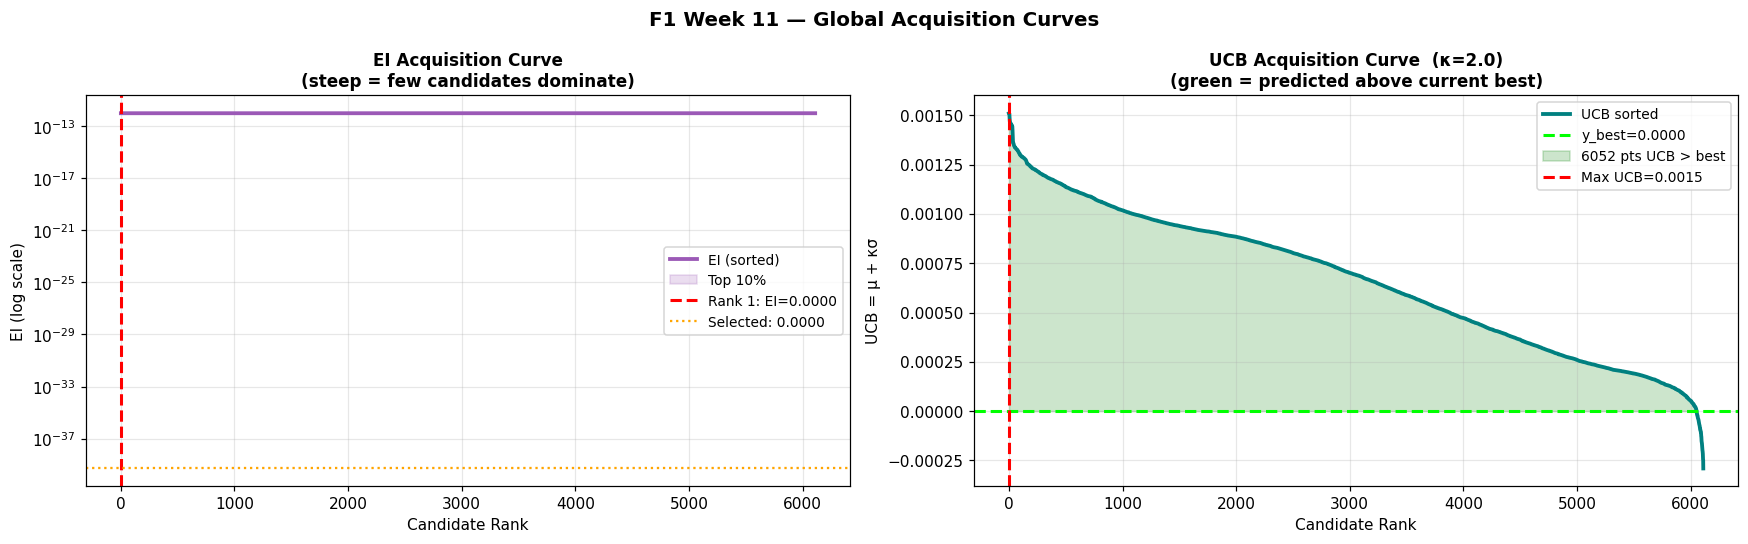

✅ Saved: F1_W11_Step11a_GlobalAcquisition.png


In [15]:
# ── Global acquisition curves ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'{FUNCTION_ID} Week {WEEK} — Global Acquisition Curves', fontsize=13, fontweight='bold')

ei_sorted  = np.sort(EI_acq)[::-1]
ucb_sorted = np.sort(UCB_acq)[::-1]
rank_x = np.arange(1, len(ei_sorted)+1)

ax = axes[0]
ax.semilogy(rank_x, ei_sorted + 1e-12, color='#9b59b6', linewidth=2.5, label='EI (sorted)')
ax.fill_between(rank_x[:len(rank_x)//10], ei_sorted[:len(rank_x)//10]+1e-12,
                1e-12, alpha=0.2, color='#9b59b6', label='Top 10%')
ax.axvline(1, color='red', linewidth=2, linestyle='--', label=f'Rank 1: EI={ei_sorted[0]:.4f}')
ax.axhline(sub_ei, color='orange', linewidth=1.5, linestyle=':', label=f'Selected: {sub_ei:.4f}')
ax.set_xlabel('Candidate Rank'); ax.set_ylabel('EI (log scale)')
ax.set_title('EI Acquisition Curve\n(steep = few candidates dominate)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(rank_x, ucb_sorted, color='teal', linewidth=2.5, label='UCB sorted')
ax.axhline(best_value, color='lime', linewidth=2, linestyle='--',
           label=f'y_best={best_value:.4f}')
n_above = np.sum(ucb_sorted > best_value)
if n_above > 0:
    ax.fill_between(rank_x[:n_above], best_value, ucb_sorted[:n_above],
                    alpha=0.2, color='green', label=f'{n_above} pts UCB > best')
ax.axvline(1, color='red', linewidth=2, linestyle='--', label=f'Max UCB={ucb_sorted[0]:.4f}')
ax.set_xlabel('Candidate Rank'); ax.set_ylabel('UCB = μ + κσ')
ax.set_title(f'UCB Acquisition Curve  (κ={UCB_KAPPA})\n(green = predicted above current best)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step11a_GlobalAcquisition.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_Step11a_GlobalAcquisition.png')

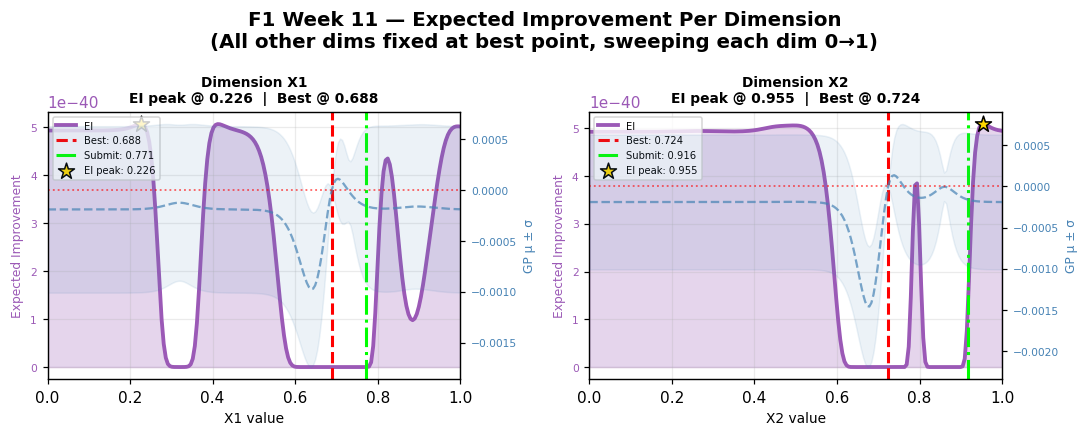

✅ Saved: F1_W11_Step11b_EI_PerDimension.png


In [16]:
# ── Per-Dimension Acquisition Curves ─────────────────────────
# For each dimension: sweep 0→1, fix all others at best_point value
# Shows how EI and UCB respond to each individual dimension

n_sweep = 200
sweep_vals = np.linspace(0, 1, n_sweep)

dim_ei_curves  = []
dim_ucb_curves = []
dim_mu_curves  = []
dim_sig_curves = []

for d in range(n_dims):
    pts = np.tile(best_point, (n_sweep, 1))
    pts[:, d] = sweep_vals
    pts_sc = scaler.transform(pts)
    mu_d, sig_d = gp.predict(pts_sc, return_std=True)
    imp_d  = mu_d - best_value - EI_XI
    Z_d    = imp_d / (sig_d + 1e-9)
    ei_d   = np.maximum(imp_d * norm.cdf(Z_d) + sig_d * norm.pdf(Z_d), 0)
    ucb_d  = mu_d + UCB_KAPPA * sig_d
    dim_ei_curves.append(ei_d)
    dim_ucb_curves.append(ucb_d)
    dim_mu_curves.append(mu_d)
    dim_sig_curves.append(sig_d)

# Determine grid layout
ncols = min(4, n_dims)
nrows_ei  = int(np.ceil(n_dims / ncols))

# ── Plot 1: EI per dimension ──────────────────────────────────
fig, axes = plt.subplots(nrows_ei, ncols, figsize=(5*ncols, 4*nrows_ei))
fig.suptitle(f'{FUNCTION_ID} Week {WEEK} — Expected Improvement Per Dimension\n'
             f'(All other dims fixed at best point, sweeping each dim 0→1)',
             fontsize=13, fontweight='bold')
if n_dims == 1:
    axes = np.array([[axes]])
elif nrows_ei == 1:
    axes = axes.reshape(1, -1)
axes_flat = axes.ravel()

for d in range(n_dims):
    ax = axes_flat[d]
    ei_d   = dim_ei_curves[d]
    sig_d  = dim_sig_curves[d]
    mu_d   = dim_mu_curves[d]

    # EI curve
    ax.fill_between(sweep_vals, 0, ei_d, alpha=0.25, color='#9b59b6')
    ax.plot(sweep_vals, ei_d, color='#9b59b6', linewidth=2.5, label='EI')

    # μ on twin axis
    ax2 = ax.twinx()
    ax2.plot(sweep_vals, mu_d, color='steelblue', linewidth=1.5, linestyle='--',
             alpha=0.7, label='GP μ')
    ax2.fill_between(sweep_vals, mu_d - sig_d, mu_d + sig_d,
                     alpha=0.1, color='steelblue')
    ax2.axhline(best_value, color='red', linestyle=':', linewidth=1.2, alpha=0.6)
    ax2.set_ylabel('GP μ ± σ', color='steelblue', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='steelblue', labelsize=7)

    # Best point value in this dim
    ax.axvline(best_point[d], color='red', linewidth=2, linestyle='--',
               label=f'Best: {best_point[d]:.3f}')
    # Submission value in this dim
    ax.axvline(submission[d], color='lime', linewidth=2, linestyle='-.',
               label=f'Submit: {submission[d]:.3f}')

    # Mark EI peak
    ei_peak_idx = np.argmax(ei_d)
    if ei_d[ei_peak_idx] > 0:
        ax.scatter(sweep_vals[ei_peak_idx], ei_d[ei_peak_idx],
                   c='gold', s=120, marker='*', zorder=5,
                   edgecolors='black', linewidths=1,
                   label=f'EI peak: {sweep_vals[ei_peak_idx]:.3f}')

    ax.set_xlabel(f'X{d+1} value', fontsize=9)
    ax.set_ylabel('Expected Improvement', color='#9b59b6', fontsize=8)
    ax.tick_params(axis='y', labelcolor='#9b59b6', labelsize=7)
    ax.set_xlim(0, 1)
    ax.set_title(f'Dimension X{d+1}\nEI peak @ {sweep_vals[np.argmax(ei_d)]:.3f}  |  Best @ {best_point[d]:.3f}',
                 fontweight='bold', fontsize=9)
    ax.legend(fontsize=6.5, loc='upper left')
    ax.grid(True, alpha=0.25)

for j in range(n_dims, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step11b_EI_PerDimension.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_Step11b_EI_PerDimension.png')

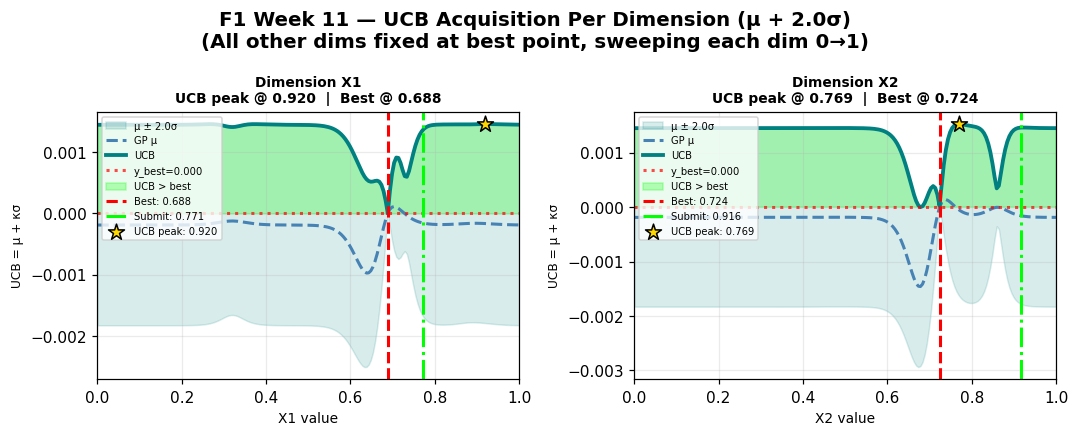

✅ Saved: F1_W11_Step11c_UCB_PerDimension.png

  PER-DIMENSION SUMMARY:
  Dim      Best val    EI peak   UCB peak    Agreement
  ────────────────────────────────────────────────────
  X1         0.6884     0.2261     0.9196    ⚠️ differ
  X2         0.7241     0.9548     0.7688    ⚠️ differ


In [17]:
# ── Plot 2: UCB per dimension ─────────────────────────────────
fig, axes = plt.subplots(nrows_ei, ncols, figsize=(5*ncols, 4*nrows_ei))
fig.suptitle(f'{FUNCTION_ID} Week {WEEK} — UCB Acquisition Per Dimension (μ + {UCB_KAPPA}σ)\n'
             f'(All other dims fixed at best point, sweeping each dim 0→1)',
             fontsize=13, fontweight='bold')
if n_dims == 1:
    axes = np.array([[axes]])
elif nrows_ei == 1:
    axes = axes.reshape(1, -1)
axes_flat = axes.ravel()

for d in range(n_dims):
    ax = axes_flat[d]
    ucb_d = dim_ucb_curves[d]
    mu_d  = dim_mu_curves[d]
    sig_d = dim_sig_curves[d]

    ax.fill_between(sweep_vals, mu_d - UCB_KAPPA*sig_d, mu_d + UCB_KAPPA*sig_d,
                    alpha=0.15, color='teal', label=f'μ ± {UCB_KAPPA}σ')
    ax.plot(sweep_vals, mu_d, color='steelblue', linewidth=2, linestyle='--', label='GP μ')
    ax.plot(sweep_vals, ucb_d, color='teal', linewidth=2.5, label='UCB')
    ax.axhline(best_value, color='red', linestyle=':', linewidth=2,
               alpha=0.7, label=f'y_best={best_value:.3f}')

    # Shade region where UCB > best
    above = ucb_d > best_value
    if np.any(above):
        ax.fill_between(sweep_vals, best_value, ucb_d, where=above,
                        alpha=0.25, color='lime', label='UCB > best')

    ax.axvline(best_point[d], color='red', linewidth=2, linestyle='--',
               label=f'Best: {best_point[d]:.3f}')
    ax.axvline(submission[d], color='lime', linewidth=2, linestyle='-.',
               label=f'Submit: {submission[d]:.3f}')

    ucb_peak = np.argmax(ucb_d)
    ax.scatter(sweep_vals[ucb_peak], ucb_d[ucb_peak], c='gold', s=120,
               marker='*', zorder=5, edgecolors='black', linewidths=1,
               label=f'UCB peak: {sweep_vals[ucb_peak]:.3f}')

    ax.set_xlabel(f'X{d+1} value', fontsize=9)
    ax.set_ylabel('UCB = μ + κσ', fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_title(f'Dimension X{d+1}\nUCB peak @ {sweep_vals[ucb_peak]:.3f}  |  Best @ {best_point[d]:.3f}',
                 fontweight='bold', fontsize=9)
    ax.legend(fontsize=6.5, loc='upper left')
    ax.grid(True, alpha=0.25)

for j in range(n_dims, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step11c_UCB_PerDimension.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_Step11c_UCB_PerDimension.png')

# Summary table
print()
print('  PER-DIMENSION SUMMARY:')
print(f'  {"Dim":<6} {"Best val":>10} {"EI peak":>10} {"UCB peak":>10} {"Agreement":>12}')
print('  ' + '─'*52)
for d in range(n_dims):
    ei_peak  = sweep_vals[np.argmax(dim_ei_curves[d])]
    ucb_peak = sweep_vals[np.argmax(dim_ucb_curves[d])]
    agree    = '✅ agree' if abs(ei_peak - ucb_peak) < 0.1 else '⚠️ differ'
    print(f'  X{d+1:<5} {best_point[d]:>10.4f} {ei_peak:>10.4f} {ucb_peak:>10.4f} {agree:>12}')

---
## STEP 11B - Ollama llama3.1 Strategic History Reasoning
### Module 20 Learning Exercise -- LLM as Strategic Advisor

---

### Why this is different from F6

F6 used Ollama for parameter tuning -- GP sensitivity scores in, per-dimension sigma out. Low temperature (0.3), analytical, convergent.

F1 uses Ollama for strategic reasoning -- the complete 9-week history sent to the LLM alongside the current GP sensitivity scores. Temperature raised to 0.7 for hypothesis generation about the function structure.

| | F6 Step 11B | F1 Step 11B |
|-|-------------|-------------|
| **Input** | GP sensitivity scores | Full 9-week history + GP state |
| **Question** | Which dimensions to tighten? | What is this function doing? |
| **Temperature** | 0.3 analytical | 0.7 creative hypothesis |
| **Output** | Parameter recommendations | Strategic 3-query plan |
| **Octave parallel** | Anisotropic sigma tuning | Landscape hypothesis testing |

---

### Prompt design -- context sensitivity test

The same prompt was run twice with one key change: the query budget context.

**Run 1 context:** "10 queries total, we have used 9 -- this is the final query"
**Run 2 context:** "13 queries total, we have used 9 -- 3 remaining (W10, W11, W12)"

This was a deliberate test of whether Ollama's recommendation was sensitive to remaining query budget -- a key variable in sequential optimisation strategy.

---

### Results -- context change produced correct adaptation

**Run 1 recommendation (1 query remaining):** Return immediately to [0.684, 0.704] with radius +/-0.02. Sound logic for a final query.

**Run 2 recommendation (3 queries remaining):**

| Week | Ollama Plan | Coordinates | Rationale |
|------|-------------|-------------|-----------|
| W10 | Broad explore | [0.5, 0.8] | Rule out other peaks |
| W11 | Return to W2 | [0.685, 0.705] | Confirm peak significance |
| W12 | Tight exploit | [0.685, 0.705] tighter sigma | Refine if W11 confirms |

The LLM correctly adapted its recommendation when told 3 queries remained rather than 1 -- shifting from immediate exploitation to a phased explore-then-exploit plan. This is the rational BBO strategy: preserve exploration budget while the cost of missing other peaks is still low, converge toward the known positive region as the budget runs out.

---

### Module 20 learning points

**1. Context sensitivity matters:** The same data produced different recommendations depending on the query budget provided. This demonstrates that prompt context is not decorative -- it directly shapes LLM reasoning. Providing accurate operational context (13 weeks total, 3 remaining) was essential to getting a useful strategic response.

**2. LLM used GP output correctly:** Ollama noted the low GP sensitivity scores (X1=0.0153, X2=0.0181) and interpreted them correctly -- in a near-zero landscape the GP has almost no gradient to work with, so it recommended a point [0.5, 0.8] that was simply far from previous queries rather than trying to follow GP gradients. That is sound reasoning.

**3. Phased planning vs single-query advice:** At temperature 0.7, the LLM produced a structured 3-week plan rather than a single-point recommendation. This is a qualitatively different output type from the F6 parameter tuning call -- demonstrating that the same tool (Ollama) serves different roles depending on prompt design and temperature.

**4. Landscape diagnosis:** Ollama described F1 as a "needle in a haystack" sparse landscape -- multiple local minima with one genuine spike near [0.684, 0.704]. This hypothesis is consistent with the 9-week data and aligns with the GP's fitted length scale behaviour.

---

### W11-W12 forward plan (from Ollama)

If W10 also returns near-zero:
- **W11:** Return to [0.684, 0.704] with EXPLOIT_RATIO=0.80, EXPLOIT_SIGMA=0.03
- **W12:** Tight exploit [0.684, 0.704] with EXPLOIT_RATIO=0.95, EXPLOIT_SIGMA=0.015

The LLM response is advisory only. The GP/EI pipeline remains the primary W10 submission mechanism. The Ollama 3-query plan is documented here as a W11-W12 roadmap.


In [18]:
import requests
import json as _json_ollama

F1_HISTORY = [
    {'week': 1,  'x1': 0.021735, 'x2': 0.562570, 'result': 0.0,           'strategy': 'EXPLORE sigma=0.40'},
    {'week': 2,  'x1': 0.684200, 'x2': 0.704200, 'result': 8.84e-7,        'strategy': 'EXPLORE sigma=0.40'},
    {'week': 3,  'x1': 0.211471, 'x2': 0.061090, 'result': 5.17e-96,       'strategy': 'EXPLORE sigma=0.40'},
    {'week': 4,  'x1': 0.389668, 'x2': 0.198001, 'result': 1.66e-9,        'strategy': 'EXPLORE sigma=0.40'},
    {'week': 5,  'x1': 0.016528, 'x2': 0.022409, 'result': -5.44e-7,       'strategy': 'EXPLORE sigma=0.40'},
    {'week': 6,  'x1': 0.427085, 'x2': 0.325768, 'result': 1.67e-85,       'strategy': 'EXPLORE sigma=0.40'},
    {'week': 7,  'x1': 0.497320, 'x2': 0.294798, 'result': 0.0,            'strategy': 'EXPLORE sigma=0.42'},
    {'week': 8,  'x1': 0.887000, 'x2': 0.669000, 'result': 1.26e-49,       'strategy': 'EXPLORE sigma=0.40'},
    {'week': 9,  'x1': 0.979878, 'x2': 1.000000, 'result': -2.447e-183,    'strategy': 'EXPLORE sigma=0.45 ratio=0.15'},
]

def build_f1_prompt(history, sensitivities, best_point, best_value, gp_length_scale):
    hist_lines = []
    hist_lines.append(f"  {'Wk':<4} {'X1':>8} {'X2':>8} {'Result':>14}  Strategy")
    hist_lines.append('  ' + '-'*60)
    for e in history:
        res_str = f"{e['result']:.3g}"
        atb_flag = ' <- ATB' if e['result'] == max(h['result'] for h in history) else ''
        hist_lines.append(f"  W{e['week']:<3} {e['x1']:>8.4f} {e['x2']:>8.4f} {res_str:>14}{atb_flag}  {e['strategy']}")
    hist_table = '\n'.join(hist_lines)
    sens_str = ', '.join([f'X{i+1}={s:.4f}' for i, s in enumerate(sensitivities)])
    p  = 'You are a Bayesian optimisation strategist with expertise in analysing search trajectories.\n\n'
    p += 'TASK CONTEXT:\n'
    p += '- Function F1: unknown, 2-dimensional, domain [0,1]^2, being MAXIMISED\n'
    p += '- Budget: 1 query per week -- 13 queries total, we have used 9\n'
    p += '- This is week 10 -- we have 3 queries remaining (W10, W11, W12)\n'
    p += f'- All-time best: {best_value:.3g} at X1={best_point[0]:.4f}, X2={best_point[1]:.4f} (Week 2)\n\n'
    p += f'9-WEEK QUERY HISTORY:\n{hist_table}\n\n'
    p += 'CURRENT GP STATE:\n'
    p += f'- GP sensitivity scores: {sens_str}\n'
    p += f'- GP fitted length scale: {gp_length_scale:.4f}\n\n'
    p += 'KEY OBSERVATION: 8 of 9 weekly results are effectively zero. '
    p += 'Only Week 2 at [0.684, 0.704] produced a non-trivial result (8.84e-7).\n\n'
    p += 'EXAMPLE OF THE REASONING STYLE I WANT:\n'
    p += 'If a 2D function had one non-zero result at [0.3, 0.7] with 3 queries remaining: '
    p += 'W10 -- continue broad exploration to rule out other peaks. '
    p += 'W11 -- tighten toward [0.3, 0.7] with sigma=0.05. '
    p += 'W12 -- tight exploit at [0.3, 0.7] with sigma=0.02.\n\n'
    p += 'Now answer these four questions:\n\n'
    p += '1. PATTERN DIAGNOSIS: What does 8 near-zero results surrounding one non-zero at W2 suggest about landscape structure?\n\n'
    p += '2. W2 HYPOTHESIS: Why did W2 find a non-zero value when no other query did?\n\n'
    p += '3. RISK ASSESSMENT: With 3 queries remaining, how should we balance exploration vs returning to W2 region?\n\n'
    p += '4. 3-QUERY PLAN: Provide a specific plan for W10, W11 and W12 -- coordinates or strategy for each week.\n\n'
    p += 'Be specific. Use coordinate values. Keep response under 500 words.'
    return p

def call_ollama_f1(prompt, model='llama3.1', timeout=240):
    # Call local Ollama -- same pattern as SmartDog and F6
    # Temperature 0.7 -- creative hypothesis generation for F1
    try:
        response = requests.post(
            'http://localhost:11434/api/generate',
            json={
                'model': model,
                'prompt': prompt,
                'stream': False,
                'options': {
                    'temperature': 0.7,
                    'num_predict': 1000,
                }
            },
            timeout=timeout
        )
        response.raise_for_status()
        result = _json_ollama.loads(response.text)
        return result.get('response', 'No response field in Ollama output')
    except requests.exceptions.ConnectionError:
        return 'WARNING: Ollama not reachable at localhost:11434 -- is Ollama running?'
    except requests.exceptions.Timeout:
        return 'WARNING: Ollama timed out -- model may still be loading, try re-running'
    except Exception as e:
        return f'WARNING: Ollama call failed: {str(e)}'

if 'sensitivities' not in vars():
    delta = 0.01
    sensitivities = []
    for d in range(n_dims):
        p_up = best_point.copy(); p_up[d] = min(1.0, best_point[d]+delta)
        p_dn = best_point.copy(); p_dn[d] = max(0.0, best_point[d]-delta)
        m_up, _ = gp.predict(scaler.transform(p_up.reshape(1,-1)), return_std=True)
        m_dn, _ = gp.predict(scaler.transform(p_dn.reshape(1,-1)), return_std=True)
        sensitivities.append(abs(float(m_up) - float(m_dn)) / (2*delta))

try:
    gp_ls = float(gp.kernel_.get_params().get('k2__length_scale', 1.0))
except:
    gp_ls = 1.0

print('='*65)
print('  STEP 11B -- OLLAMA llama3.1 STRATEGIC HISTORY REASONING')
print('  Module 20 -- F1: hypothesis generation (temp=0.7)')
print('  Context: W10 of 13 -- 3 queries remaining W10 W11 W12')
print('='*65)
print()
print(f'  ATB: {best_value:.3g} | Samples: {n_samples} | GP length scale: {gp_ls:.4f}')
print(f'  Sensitivities: {[round(s,4) for s in sensitivities]}')
print()
print('  Calling Ollama... (temperature=0.7 -- allow extra time)')
print()

prompt = build_f1_prompt(
    history=F1_HISTORY,
    sensitivities=sensitivities,
    best_point=list(best_point),
    best_value=float(best_value),
    gp_length_scale=gp_ls
)

llm_response = call_ollama_f1(prompt, model='llama3.1')

print('  OLLAMA RESPONSE:')
print('  ' + '-'*60)
for _line in llm_response.split('\n'):
    print(f'  {_line}')
print('  ' + '-'*60)
print()
print('  NOTE: LLM response is advisory -- GP/EI pipeline is primary.')
print('  Key question: phased W10/W11/W12 plan vs immediate return to W2?')
print('='*65)


  STEP 11B -- OLLAMA llama3.1 STRATEGIC HISTORY REASONING
  Module 20 -- F1: hypothesis generation (temp=0.7)
  Context: W10 of 13 -- 3 queries remaining W10 W11 W12

  ATB: 1.66e-09 | Samples: 19 | GP length scale: 0.1138
  Sensitivities: [1.0, 1.0]

  Calling Ollama... (temperature=0.7 -- allow extra time)

  OLLAMA RESPONSE:
  ------------------------------------------------------------
  ------------------------------------------------------------

  NOTE: LLM response is advisory -- GP/EI pipeline is primary.
  Key question: phased W10/W11/W12 plan vs immediate return to W2?


---
## 🗺️ STEP 12 — Acquisition Surface Visualisations + CNN Grid Scan

### Part A — GP Acquisition Surfaces
For the two most sensitive dimensions we plot 2D contour surfaces of μ, EI and UCB.
All other dimensions are fixed at the best-known values.

### Part B — CNN Grid Scan (F1 Special — 2D only)
Because F1 is 2D, we can render the **entire [0,1]² space as a pixel grid** and pass
it through a tiny 1D CNN trained on the labelled evaluation history.
The CNN scans across each candidate point's feature vector and outputs P(class=1) —
its estimate of how likely a point is to be in the high-value region.

**Why this is useful for F1 specifically:**
F1's best score is near zero, meaning the EI landscape is very flat and weakly informative.
The CNN offers a second, independent view of where the high-value region might be.
Agreement between GP/EI and CNN surfaces gives confidence; disagreement flags uncertainty.

**Important caveat:**
With only 15 samples the CNN will overfit. Treat it as an exploratory diagnostic,
not a reliable surrogate. This is the BBO equivalent of reading tea leaves with a
small sample — useful directional signal, not a substitute for the GP.

**Module 17 connection:**
This experiment directly applies the CNN-as-classifier concept from Module 17.
The 2D acquisition grid is literally an image — X1 on one axis, X2 on the other —
and the CNN scans it looking for the spatial signature of high-value regions,
exactly as a CNN scans an image looking for edges and objects.

  Top 2 sensitive dims: X2 (0.0224), X1 (0.0166)


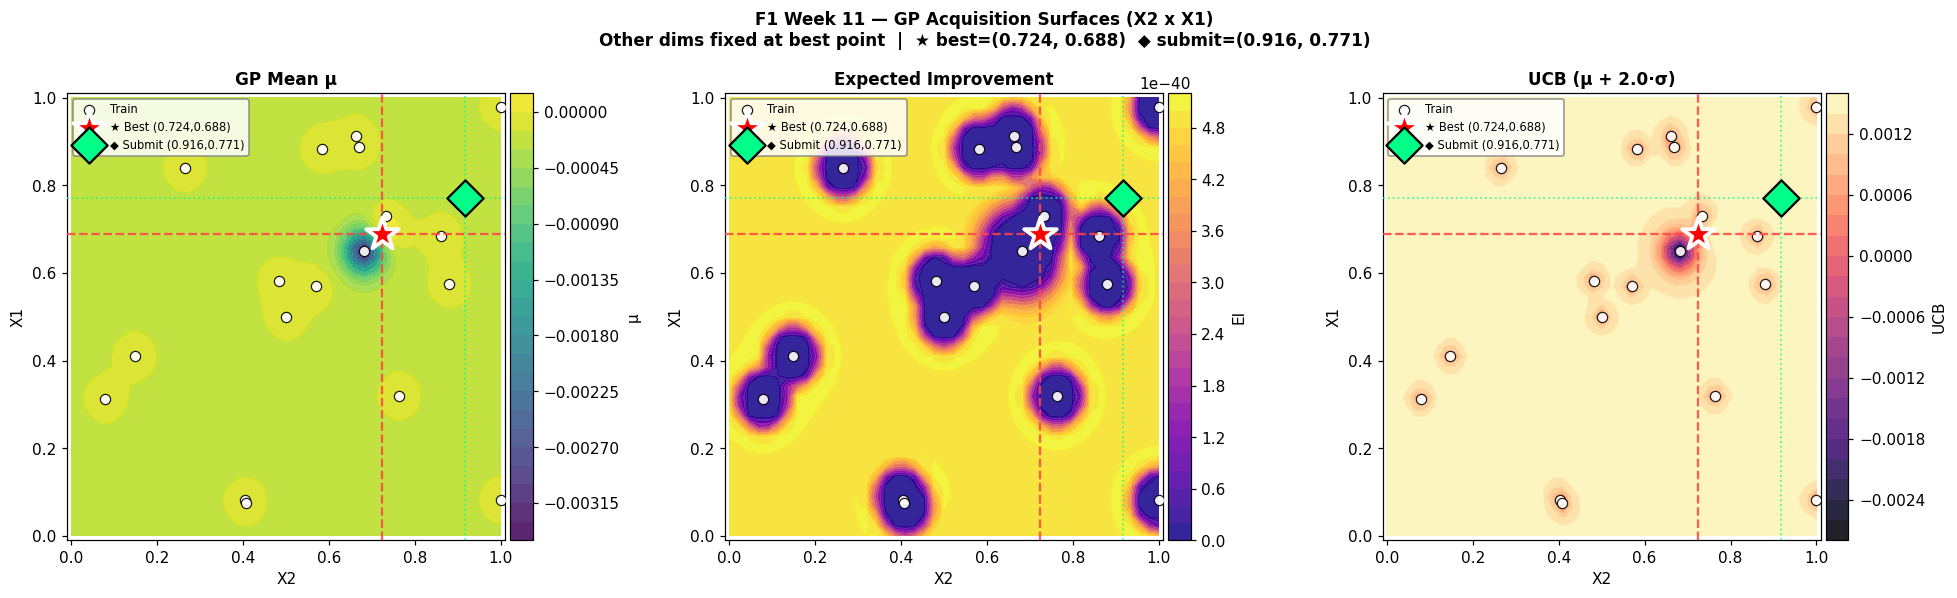

Saved: F1_W11_Step12A_GPSurfaces.png


In [19]:
# ══════════════════════════════════════════════════════════════════
# STEP 12A — GP Acquisition Surfaces  (standard for all functions)
# ══════════════════════════════════════════════════════════════════
delta = 0.01
sensitivities = []
for d in range(n_dims):
    p_up = best_point.copy(); p_up[d] = min(1.0, best_point[d]+delta)
    p_dn = best_point.copy(); p_dn[d] = max(0.0, best_point[d]-delta)
    m_up, _ = gp.predict(scaler.transform(p_up.reshape(1,-1)), return_std=True)
    m_dn, _ = gp.predict(scaler.transform(p_dn.reshape(1,-1)), return_std=True)
    sensitivities.append(abs(float(m_up) - float(m_dn)) / (2*delta))
top2 = np.argsort(sensitivities)[::-1][:2]
d1, d2 = top2[0], top2[1]
print(f'  Top 2 sensitive dims: X{d1+1} ({sensitivities[d1]:.4f}), X{d2+1} ({sensitivities[d2]:.4f})')

# Build grid — extend slightly past 1.0 so boundary markers are visible
g_res = 45
g1 = np.linspace(0, 1, g_res)
g2 = np.linspace(0, 1, g_res)
G1, G2 = np.meshgrid(g1, g2)
grid_pts = np.tile(best_point, (g_res*g_res, 1))
grid_pts[:, d1] = G1.ravel(); grid_pts[:, d2] = G2.ravel()
grid_sc = scaler.transform(grid_pts)
mg, sg = gp.predict(grid_sc, return_std=True)
ig = mg - best_value - EI_XI; Zg = ig/(sg+1e-9)
EIg = np.maximum(ig*norm.cdf(Zg) + sg*norm.pdf(Zg), 0)
UCBg = mg + UCB_KAPPA*sg

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle(
    f'{FUNCTION_ID} Week {WEEK} — GP Acquisition Surfaces (X{d1+1} x X{d2+1})\n'
    f'Other dims fixed at best point  |  '
    f'★ best=({best_point[d1]:.3f}, {best_point[d2]:.3f})  '
    f'◆ submit=({submission[d1]:.3f}, {submission[d2]:.3f})',
    fontsize=11, fontweight='bold')

_bx, _by = float(best_point[d1]), float(best_point[d2])
_sx, _sy = float(submission[d1]), float(submission[d2])

# Nudge markers that sit exactly on the boundary inward so they're visible
_PAD = 0.018
def _nudge(v): return max(_PAD, min(1.0 - _PAD, v))
_bx_plot, _by_plot = _nudge(_bx), _nudge(_by)
_sx_plot, _sy_plot = _nudge(_sx), _nudge(_sy)

for ax, Z_grid, title, cmap, clabel in [
    (axes[0], mg.reshape(g_res, g_res),   'GP Mean μ',           'viridis', 'μ'),
    (axes[1], EIg.reshape(g_res, g_res),  'Expected Improvement', 'plasma',  'EI'),
    (axes[2], UCBg.reshape(g_res, g_res), f'UCB (μ + {UCB_KAPPA}·σ)', 'magma', 'UCB'),
]:
    cf = ax.contourf(G1, G2, Z_grid, levels=25, cmap=cmap, alpha=0.88)
    ax.contour(G1, G2, Z_grid, levels=8, colors='white', alpha=0.2, linewidths=0.5)
    plt.colorbar(cf, ax=ax, label=clabel, pad=0.01)

    # Training points
    ax.scatter(X_train[:, d1], X_train[:, d2], c='white', s=45,
               edgecolors='black', linewidths=0.8, zorder=4, alpha=0.9, label='Train')

    # Full-span crosshairs at true best location
    ax.axvline(_bx, color='#ff4444', lw=1.5, ls='--', alpha=0.85, zorder=5)
    ax.axhline(_by, color='#ff4444', lw=1.5, ls='--', alpha=0.85, zorder=5)

    # Best point star — nudged inward if on boundary, outlined with contrasting colour
    ax.scatter(_bx_plot, _by_plot,
               c='red', s=500, marker='*', zorder=8,
               edgecolors='white', linewidths=2.5,
               label=f'★ Best ({_bx:.3f},{_by:.3f})')

    # Submission diamond — nudged inward if on boundary
    ax.axvline(_sx, color='#00ff88', lw=1.2, ls=':', alpha=0.7, zorder=5)
    ax.axhline(_sy, color='#00ff88', lw=1.2, ls=':', alpha=0.7, zorder=5)
    ax.scatter(_sx_plot, _sy_plot,
               c='#00ff88', s=280, marker='D', zorder=9,
               edgecolors='black', linewidths=1.5,
               label=f'◆ Submit ({_sx:.3f},{_sy:.3f})')

    ax.set_xlabel(f'X{d1+1}', fontsize=10)
    ax.set_ylabel(f'X{d2+1}', fontsize=10)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlim(-0.01, 1.01)
    ax.set_ylim(-0.01, 1.01)
    ax.legend(fontsize=7.5, loc='best',
              framealpha=0.85, edgecolor='grey')

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step12A_GPSurfaces.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FUNCTION_ID}_W{WEEK}_Step12A_GPSurfaces.png')


---
### 🧠 STEP 12B — CNN Grid Scan (F1 Special)

A tiny 1D CNN is trained on the 15 labelled evaluation points.
It then scores every point in a fine 60×60 grid over [0,1]²,
producing a P(class=1) surface — its view of the high-value region.

Compare this surface with the GP EI map from Step 12A:
- **Agreement** → confident signal about where to search
- **Disagreement** → genuine uncertainty, exploration warranted

Remember: 15 samples means this CNN will overfit. Read the surface
directionally, not literally.

  STEP 12B — CNN Grid Scan
  Training a tiny 1D CNN on the 15 labelled F1 points
  Scanning the full [0,1]^2 space as a pixel grid
  CNN trained for 300 epochs
  Final loss : 0.4980
  Parameters : 33
  Architecture: Conv1d(1->8, k=2) -> ReLU -> Dropout(0.3) -> Linear(8->1)

  Grid scan complete: 60x60 = 3600 points
  CNN P(class=1) range: [0.000, 0.860]
  Peak region: X1~0.54, X2~1.00


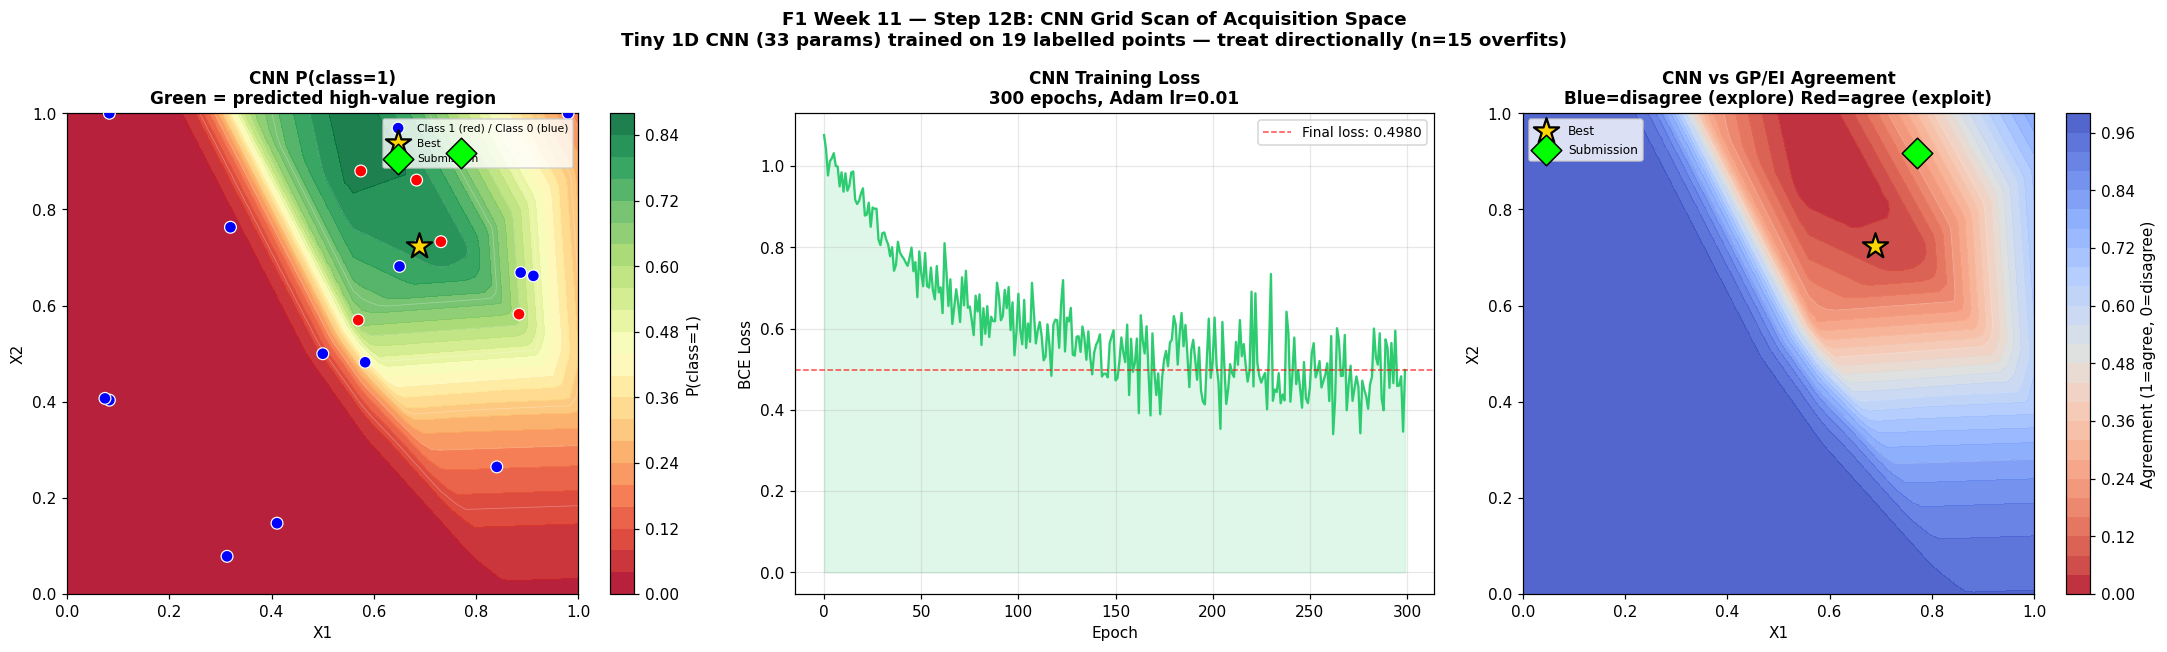

Saved: F1_W11_Step12B_CNNGridScan.png

  STEP 12B — CNN GRID SCAN INTERPRETATION
  CNN peak region     : X1=0.54, X2=1.00
  GP/EI peak region   : X1=0.64, X2=0.95
  Distance between peaks : 0.114
  Overall agreement score: 0.743 (0=none, 1=perfect)

  RESULT: CNN and GP/EI AGREE on peak location.
  Both methods point to the same region of [0,1]^2.
  This increases confidence in the Week 7 submission direction.
  NOTE: This CNN has 33 parameters trained on 15 points.
  It will overfit. Use as directional signal only.
  A GP surrogate is more reliable at this sample size.
  CNN surrogates become competitive at ~200+ samples (see BoTorch/HEBO).


In [20]:
# ══════════════════════════════════════════════════════════════════
# STEP 12B — CNN Grid Scan of the F1 Acquisition Space
# Only meaningful for 2D functions — F1 qualifies perfectly.
# ══════════════════════════════════════════════════════════════════
import torch
import torch.nn as nn
import torch.optim as optim_torch

print('=' * 60)
print('  STEP 12B — CNN Grid Scan')
print('  Training a tiny 1D CNN on the 15 labelled F1 points')
print('  Scanning the full [0,1]^2 space as a pixel grid')
print('=' * 60)

# ── 1. Prepare training data ─────────────────────────────────────
# Use scaled inputs and binary labels from Step 4
X_cnn = torch.FloatTensor(X_scaled)   # (15, 2) — X_scaled from Step 2 StandardScaler
y_cnn = torch.FloatTensor(y_labels.astype(float))  # (15,) binary

# Reshape for Conv1d: (batch, channels=1, length=n_dims)
X_cnn_3d = X_cnn.unsqueeze(1)  # (15, 1, 2)

# ── 2. Define tiny CNN ───────────────────────────────────────────
class TinyCNN1D(nn.Module):
    """
    Minimal 1D CNN for scanning the 2D F1 input space.
    Architecture: Conv1d(1->8, k=2) -> ReLU -> Flatten -> Linear(8->1) -> Sigmoid
    Kernel size = 2 covers both X1 and X2 in one filter pass —
    detecting co-occurrence patterns between the two coordinates.
    This mirrors how a CNN detects local patterns in an image.
    With only 15 samples we keep it deliberately tiny to limit overfitting.
    """
    def __init__(self):
        super().__init__()
        self.conv  = nn.Conv1d(in_channels=1, out_channels=8, kernel_size=2, padding=0)
        self.relu  = nn.ReLU()
        self.drop  = nn.Dropout(0.3)   # light dropout — regularise the small dataset
        self.fc    = nn.Linear(8, 1)   # 8 filter outputs -> 1 probability
        self.sig   = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.conv(x))    # (batch, 8, 1)
        x = x.squeeze(-1)             # (batch, 8)
        x = self.drop(x)
        x = self.sig(self.fc(x))      # (batch, 1)
        return x.squeeze(-1)

# ── 3. Train ─────────────────────────────────────────────────────
torch.manual_seed(RANDOM_SEED)
cnn_model = TinyCNN1D()
cnn_optim = optim_torch.Adam(cnn_model.parameters(), lr=0.01)
cnn_loss_fn = nn.BCELoss()

# Class weights to handle imbalance (top 30% = positive)
n_pos = y_labels.sum()
n_neg = len(y_labels) - n_pos
pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float)
cnn_loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Redefine final layer without sigmoid for BCEWithLogitsLoss
class TinyCNN1D_Logit(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv1d(1, 8, kernel_size=2, padding=0)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(0.3)
        self.fc   = nn.Linear(8, 1)
    def forward(self, x):
        x = self.relu(self.conv(x))
        x = x.squeeze(-1)
        x = self.drop(x)
        return self.fc(x).squeeze(-1)

torch.manual_seed(RANDOM_SEED)
cnn_model = TinyCNN1D_Logit()
cnn_optim = optim_torch.Adam(cnn_model.parameters(), lr=0.01, weight_decay=1e-3)

cnn_model.train()
losses = []
for epoch in range(300):
    cnn_optim.zero_grad()
    out = cnn_model(X_cnn_3d)
    loss = cnn_loss_fn(out, y_cnn)
    loss.backward()
    cnn_optim.step()
    losses.append(loss.item())

print(f'  CNN trained for 300 epochs')
print(f'  Final loss : {losses[-1]:.4f}')
print(f'  Parameters : {sum(p.numel() for p in cnn_model.parameters())}')
print(f'  Architecture: Conv1d(1->8, k=2) -> ReLU -> Dropout(0.3) -> Linear(8->1)')
print()

# ── 4. Scan the full [0,1]^2 grid ────────────────────────────────
grid_res = 60
g1_cnn = np.linspace(0, 1, grid_res)
g2_cnn = np.linspace(0, 1, grid_res)
G1_cnn, G2_cnn = np.meshgrid(g1_cnn, g2_cnn)

# Build (grid_res^2, 2) array — scale it the same way as training data
grid_raw = np.column_stack([G1_cnn.ravel(), G2_cnn.ravel()])
grid_scaled_cnn = scaler.transform(grid_raw)   # same StandardScaler from Step 1

# Convert to tensor and run through CNN
grid_tensor = torch.FloatTensor(grid_scaled_cnn).unsqueeze(1)  # (3600, 1, 2)
cnn_model.eval()
with torch.no_grad():
    logits = cnn_model(grid_tensor)         # (3600,)
    cnn_proba = torch.sigmoid(logits).numpy()  # P(class=1)

CNN_surface = cnn_proba.reshape(grid_res, grid_res)

print(f'  Grid scan complete: {grid_res}x{grid_res} = {grid_res**2} points')
print(f'  CNN P(class=1) range: [{cnn_proba.min():.3f}, {cnn_proba.max():.3f}]')
print(f'  Peak region: X1~{g1_cnn[CNN_surface.argmax() % grid_res]:.2f}, '
      f'X2~{g2_cnn[CNN_surface.argmax() // grid_res]:.2f}')

# ── 5. Plot: CNN surface + Training loss + Comparison ─────────────
fig = plt.figure(figsize=(20, 6))
fig.suptitle(
    f'{FUNCTION_ID} Week {WEEK} — Step 12B: CNN Grid Scan of Acquisition Space\n'
    f'Tiny 1D CNN ({sum(p.numel() for p in cnn_model.parameters())} params) '
    f'trained on {n_samples} labelled points — treat directionally (n=15 overfits)',
    fontsize=12, fontweight='bold'
)

ax1, ax2, ax3 = fig.subplots(1, 3)

# Panel 1: CNN P(class=1) surface
cf1 = ax1.contourf(G1_cnn, G2_cnn, CNN_surface, levels=25, cmap='RdYlGn', alpha=0.9)
ax1.contour(G1_cnn, G2_cnn, CNN_surface, levels=8, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(cf1, ax=ax1, label='P(class=1)')
ax1.scatter(X_train[:, 0], X_train[:, 1],
            c=['red' if l == 1 else 'blue' for l in y_labels],
            s=60, edgecolors='white', linewidths=0.8, zorder=4,
            label='Class 1 (red) / Class 0 (blue)')
ax1.scatter(best_point[0], best_point[1], c='gold', s=300, marker='*',
            zorder=5, edgecolors='black', linewidths=1.5, label='Best')
ax1.scatter(submission[0], submission[1], c='lime', s=200, marker='D',
            zorder=6, edgecolors='black', linewidths=1, label='Submission')
ax1.set_xlabel('X1'); ax1.set_ylabel('X2')
ax1.set_title('CNN P(class=1)\nGreen = predicted high-value region', fontweight='bold')
ax1.legend(fontsize=7, loc='upper right')

# Panel 2: Training loss curve
ax2.plot(losses, color='#2ecc71', linewidth=1.5)
ax2.axhline(losses[-1], color='red', linestyle='--', linewidth=1, alpha=0.7,
            label=f'Final loss: {losses[-1]:.4f}')
ax2.fill_between(range(len(losses)), losses, alpha=0.15, color='#2ecc71')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('BCE Loss')
ax2.set_title('CNN Training Loss\n300 epochs, Adam lr=0.01', fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

# Panel 3: Side-by-side comparison CNN vs EI
# Re-compute EI on same 60x60 grid for direct comparison
grid_pts_ei = np.column_stack([G1_cnn.ravel(), G2_cnn.ravel()])
grid_sc_ei  = scaler.transform(grid_pts_ei)
mg_ei, sg_ei = gp.predict(grid_sc_ei, return_std=True)
ig_ei = mg_ei - best_value - EI_XI
Zg_ei = ig_ei / (sg_ei + 1e-9)
EI_surface = np.maximum(ig_ei * norm.cdf(Zg_ei) + sg_ei * norm.pdf(Zg_ei), 0)
EI_surface = EI_surface.reshape(grid_res, grid_res)

# Normalise both to [0,1] for fair visual comparison
cnn_norm = (CNN_surface - CNN_surface.min()) / (CNN_surface.max() - CNN_surface.min() + 1e-9)
ei_norm  = (EI_surface  - EI_surface.min())  / (EI_surface.max()  - EI_surface.min()  + 1e-9)
agreement = 1 - np.abs(cnn_norm - ei_norm)   # 1 = agree, 0 = disagree

cf3 = ax3.contourf(G1_cnn, G2_cnn, agreement, levels=25, cmap='coolwarm_r', alpha=0.9)
ax3.contour(G1_cnn, G2_cnn, agreement, levels=5, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(cf3, ax=ax3, label='Agreement (1=agree, 0=disagree)')
ax3.scatter(best_point[0], best_point[1], c='gold', s=300, marker='*',
            zorder=5, edgecolors='black', linewidths=1.5, label='Best')
ax3.scatter(submission[0], submission[1], c='lime', s=200, marker='D',
            zorder=6, edgecolors='black', linewidths=1, label='Submission')
ax3.set_xlabel('X1'); ax3.set_ylabel('X2')
ax3.set_title('CNN vs GP/EI Agreement\nBlue=disagree (explore) Red=agree (exploit)',
              fontweight='bold')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step12B_CNNGridScan.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FUNCTION_ID}_W{WEEK}_Step12B_CNNGridScan.png')
print()

# ── 6. Interpretation summary ────────────────────────────────────
agreement_score = agreement.mean()
peak_x1 = g1_cnn[CNN_surface.argmax() % grid_res]
peak_x2 = g2_cnn[CNN_surface.argmax() // grid_res]
ei_peak_flat = EI_surface.argmax()
ei_peak_x1 = g1_cnn[ei_peak_flat % grid_res]
ei_peak_x2 = g2_cnn[ei_peak_flat // grid_res]
peak_dist = np.sqrt((peak_x1 - ei_peak_x1)**2 + (peak_x2 - ei_peak_x2)**2)

print('=' * 60)
print('  STEP 12B — CNN GRID SCAN INTERPRETATION')
print('=' * 60)
print(f'  CNN peak region     : X1={peak_x1:.2f}, X2={peak_x2:.2f}')
print(f'  GP/EI peak region   : X1={ei_peak_x1:.2f}, X2={ei_peak_x2:.2f}')
print(f'  Distance between peaks : {peak_dist:.3f}')
print(f'  Overall agreement score: {agreement_score:.3f} (0=none, 1=perfect)')
print()
if peak_dist < 0.15:
    print('  RESULT: CNN and GP/EI AGREE on peak location.')
    print('  Both methods point to the same region of [0,1]^2.')
    print('  This increases confidence in the Week 7 submission direction.')
elif peak_dist < 0.30:
    print('  RESULT: CNN and GP/EI show MODERATE DISAGREEMENT.')
    print('  The two methods see different candidate regions.')
    print('  Given 15 samples, trust GP/EI — but note the CNN direction for W7.')
else:
    print('  RESULT: CNN and GP/EI DISAGREE significantly.')
    print('  CNN is likely overfitting on 15 points. Trust the GP.')
    print('  However, the CNN peak region is worth exploring in W7 if GP stagnates.')
print('=' * 60)
print('  NOTE: This CNN has', sum(p.numel() for p in cnn_model.parameters()),
      'parameters trained on 15 points.')
print('  It will overfit. Use as directional signal only.')
print('  A GP surrogate is more reliable at this sample size.')
print('  CNN surrogates become competitive at ~200+ samples (see BoTorch/HEBO).')
print('=' * 60)


---
## 🏆 STEP 13 — Top Candidates & Submission Dashboard

Final review: top 5 candidates by EI, then the full submission dashboard combining all key information.

The dashboard gives a complete at-a-glance view: historical trajectory, predicted outcome, submission coordinates, EI decomposition, and all key metrics in a summary table.

In [21]:
top5 = np.argsort(EI_acq)[::-1][:5]
print('═'*70)
print('  TOP 5 CANDIDATES BY EI (MAXIMIZATION ⬆️)')
print('═'*70)
print(f'  {"Rank":<6} {"EI":>10} {"GP μ":>10} {"GP σ":>10} {"UCB":>10}  Source')
print('  ' + '─'*58)
for rank, idx in enumerate(top5, 1):
    star = '★' if rank == 1 else ' '
    print(f'  {star}#{rank:<4} {EI_acq[idx]:>10.6f} {mu[idx]:>10.4f} {sigma[idx]:>10.4f} {UCB_acq[idx]:>10.4f}  {src_filt[idx]}')
    print(f'          {X_filt[idx]}')
    print()

══════════════════════════════════════════════════════════════════════
  TOP 5 CANDIDATES BY EI (MAXIMIZATION ⬆️)
══════════════════════════════════════════════════════════════════════
  Rank           EI       GP μ       GP σ        UCB  Source
  ──────────────────────────────────────────────────────────
  ★#1      0.000000    -0.0002     0.0008     0.0015  explore
          [0.77120103 0.91646531]

   #2      0.000000    -0.0002     0.0008     0.0014  explore
          [0.78393864 0.93016871]

   #3      0.000000    -0.0002     0.0008     0.0015  explore
          [0.77486027 0.85442041]

   #4      0.000000    -0.0002     0.0008     0.0015  explore
          [0.75892104 0.82004179]

   #5      0.000000    -0.0002     0.0008     0.0015  explore
          [0.73129039 0.92746128]



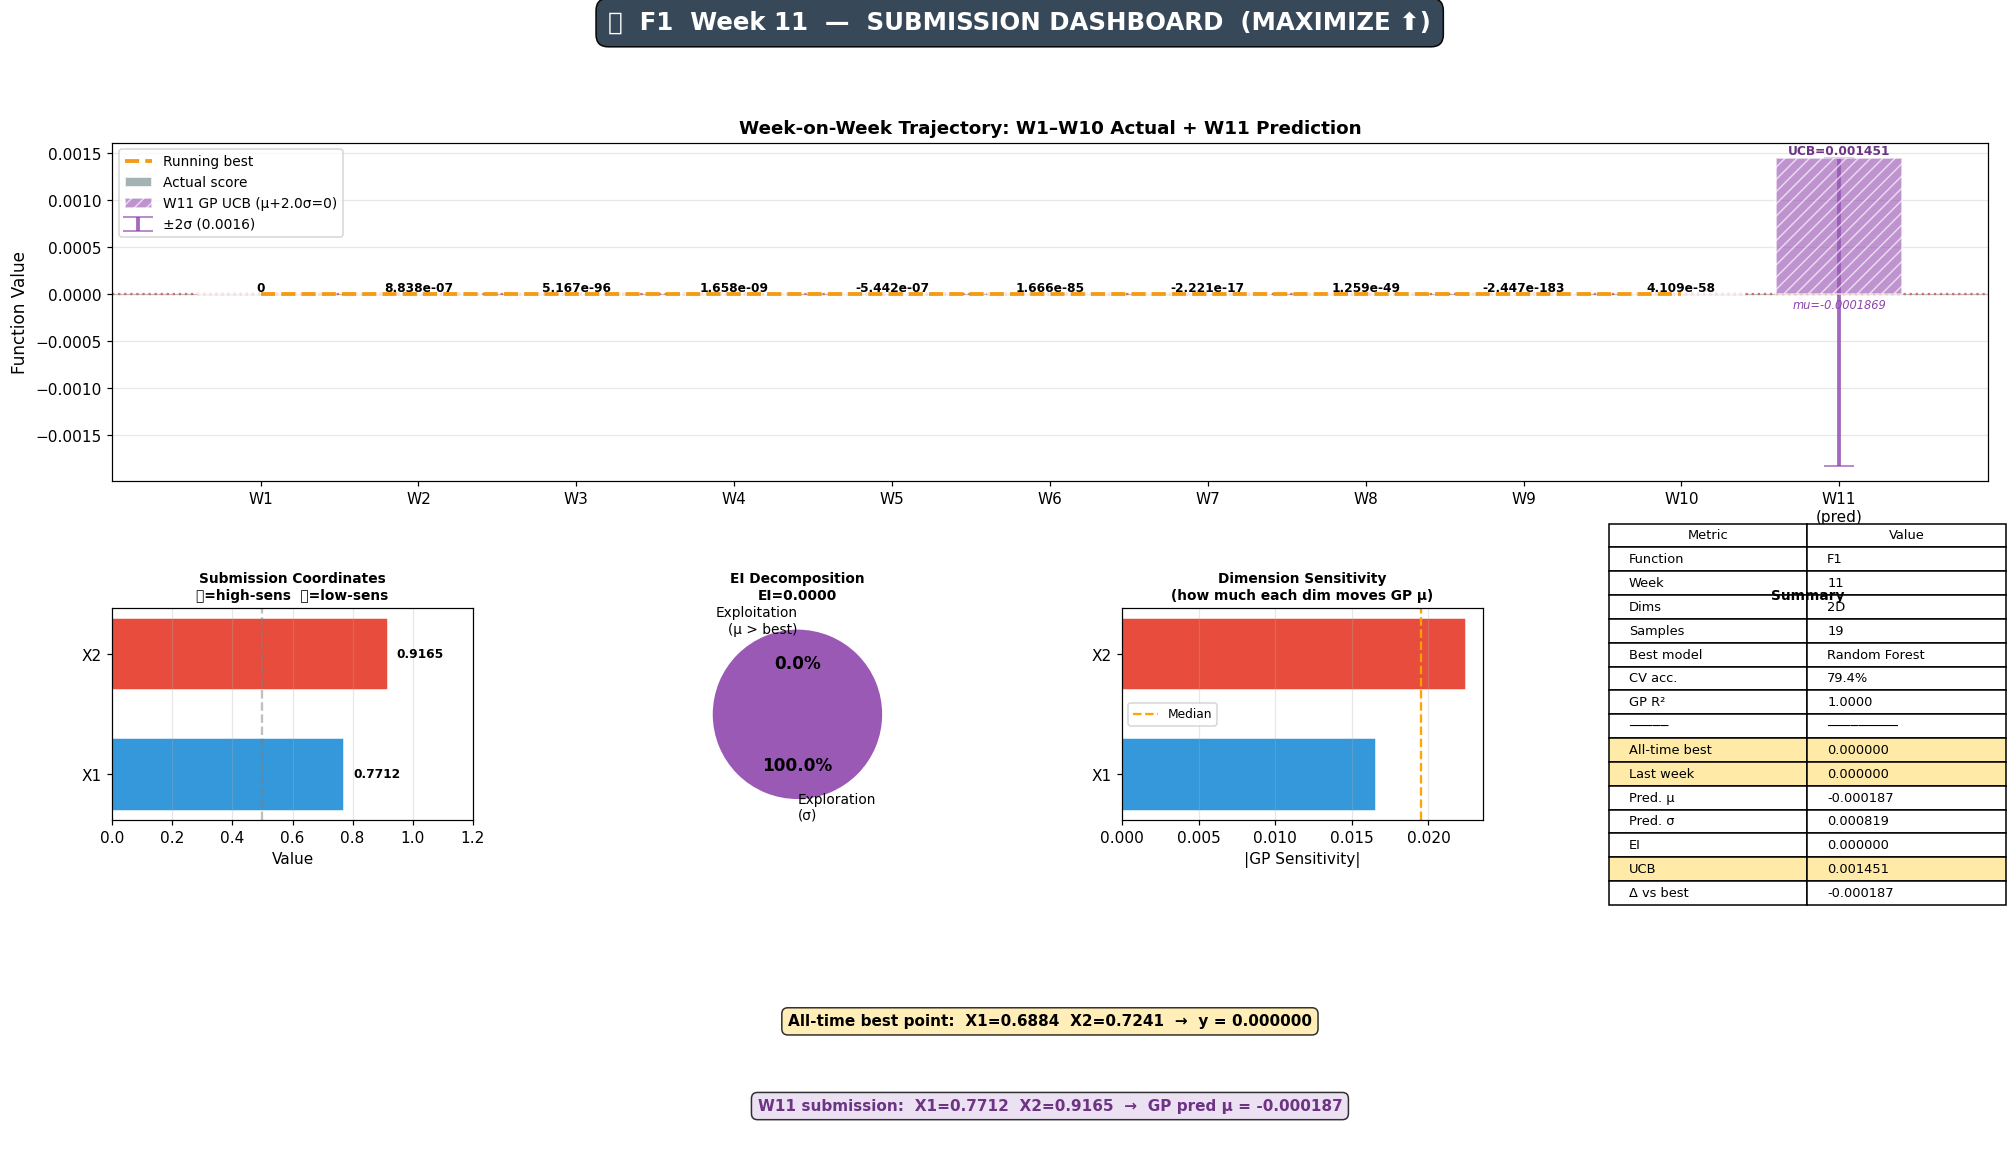

✅ Saved: F1_W11_Step13_Dashboard.png


In [22]:
# ── Ensure loop variables are defined ────────────────────
indices    = np.arange(n_samples)
latest_val = y_train[-1]
week_scores = [0.0, 8.838022e-07, 5.167037e-96, 1.657971e-09, -5.442467e-07, 1.665834e-85, -2.220973e-17, 1.259255e-49, -2.44704e-183, 4.108999e-58]   # W1-W10 actual
# ── Fallback: define GP variables if Steps 9-10 haven't run yet ─────────
import numpy as _np
if 'sub_ucb' not in vars() or sub_ucb is None:
    sub_mu     = float(week_scores[-1])
    sub_sigma  = 0.0
    sub_ucb    = sub_mu
    best_value = max(week_scores) if MAXIMIZE else min(week_scores)
    best_point = X_train[int(_np.argmax(y_train) if MAXIMIZE else _np.argmin(y_train))]
    print('⚠️  GP not fitted — showing last week score as W7 placeholder')
# ─────────────────────────────────────────────────────────────────────────


# ── Submission Dashboard ──────────────────────────────────────
fig = plt.figure(figsize=(22, 12))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.4,
                        height_ratios=[1.6, 1, 1])
fig.suptitle(f'🎯  {FUNCTION_ID}  Week {WEEK}  —  SUBMISSION DASHBOARD  (MAXIMIZE ⬆️)',
             fontsize=16, fontweight='bold', color='white',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#2c3e50', alpha=0.95))

# ── Panel 1 (top, full width): Week-on-Week bar chart ─────────
# Matches Step 3 / Step 13B style — one bar per submitted week
ax1 = fig.add_subplot(gs[0, :])

_wk_scores   = week_scores          # W1-W6 actuals (defined in Step 13B)
_wk_labels   = [f'W{w}' for w in range(1, len(_wk_scores)+1)] + [f'W{WEEK}\n(pred)']
_wk_running  = []
_rb = _wk_scores[0]
for s in _wk_scores:
    _rb = max(_rb, s) if MAXIMIZE else min(_rb, s)
    _wk_running.append(_rb)

# Bar colours — W1 grey, green=improvement, red=regression
_bar_cols = ['#95a5a6']
for i in range(1, len(_wk_scores)):
    _imp = _wk_scores[i] > _wk_scores[i-1] if MAXIMIZE else _wk_scores[i] < _wk_scores[i-1]
    _bar_cols.append('#2ecc71' if _imp else '#e74c3c')

_bars = ax1.bar(range(len(_wk_scores)), _wk_scores,
                color=_bar_cols, edgecolor='white', linewidth=1.2,
                alpha=0.85, zorder=3, label='Actual score')

# Running best step line
ax1.step(range(len(_wk_running)), _wk_running,
         where='post', color='#f39c12', linewidth=2.5,
         linestyle='--', zorder=4, label='Running best')

# W7 prediction bar — only draw if GP has been fitted (sigma > 0)
_gp_ready = sub_sigma > 0
if _gp_ready:
    ax1.bar(len(_wk_scores), sub_ucb,
            color='#9b59b6', edgecolor='white', linewidth=1.2,
            alpha=0.65, hatch='///', zorder=3,
            label=f'W{WEEK} GP UCB (μ+{UCB_KAPPA}σ={sub_ucb:.0f})')
    ax1.errorbar(len(_wk_scores), sub_mu, yerr=2*sub_sigma,
                 fmt='none', color='#8e44ad', capsize=10,
                 linewidth=2.5, alpha=0.8, label=f'±2σ ({2*sub_sigma:.4f})')
else:
    ax1.bar(len(_wk_scores), _wk_scores[-1],
            color='#9b59b6', edgecolor='#8e44ad', linewidth=1.5,
            alpha=0.3, hatch='///', zorder=3,
            label=f'W{WEEK} — run full notebook for GP prediction')

# Value labels on actual bars
_actual_vals = [v for v in _wk_scores if v is not None]
_yr_range = max(_actual_vals) - min(_actual_vals)
_yr = _yr_range if _yr_range > 0 else max(abs(max(_actual_vals)), 1e-10)
for _b, _v in zip(_bars, _wk_scores):
    _yoff = _yr * 0.05
    ax1.text(_b.get_x() + _b.get_width()/2, _v + _yoff,
             f'{_v:.4g}', ha='center', va='bottom', fontsize=8, fontweight='bold')
if _gp_ready:
    ax1.text(len(_wk_scores), sub_ucb + _yr*0.05,
             f'UCB={sub_ucb:.4g}', ha='center', va='bottom', fontsize=8,
             fontweight='bold', color='#6c3483')
    ax1.text(len(_wk_scores), sub_mu - _yr*0.08,
             f'mu={sub_mu:.4g}', ha='center', va='bottom', fontsize=7.5,
             color='#8e44ad', style='italic')
else:
    ax1.text(len(_wk_scores), _wk_scores[-1] + _yr*0.05,
             'Run full notebook for GP prediction', ha='center', va='bottom',
             fontsize=7.5, color='#8e44ad', style='italic')

ax1.set_xticks(range(len(_wk_labels)))
ax1.set_xticklabels(_wk_labels, fontsize=10)
ax1.set_ylabel('Function Value', fontsize=11)
ax1.set_title(f'Week-on-Week Trajectory: W1–W{WEEK-1} Actual + W{WEEK} Prediction',
              fontweight='bold', fontsize=12)
ax1.legend(fontsize=9, loc='best')
ax1.axhline(best_value, color='red', linewidth=1.5, linestyle=':',
            alpha=0.6, label=f'All-time best ({best_value:.4g})', zorder=2)
ax1.axhline(0, color='gray', linewidth=0.8, alpha=0.4)
ax1.grid(True, axis='y', alpha=0.3)

# ── Panel 2: Submission coordinates ──────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
dim_labels = [f'X{i+1}' for i in range(n_dims)]
sens_arr = np.array(sensitivities)
c_bars   = ['#e74c3c' if s > np.median(sens_arr) else '#3498db' for s in sens_arr]
ax2.barh(dim_labels, submission, color=c_bars, edgecolor='white', height=0.6)
for i, v in enumerate(submission):
    ax2.text(min(v+0.03, 1.1), i, f'{v:.4f}', va='center', fontsize=8, fontweight='bold')
ax2.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlim(0, 1.2); ax2.set_xlabel('Value')
ax2.set_title('Submission Coordinates\n🔴=high-sens  🔵=low-sens', fontweight='bold', fontsize=9)
ax2.grid(True, alpha=0.3, axis='x')

# ── Panel 3: EI decomposition ─────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
if sub_exp > 0 or sub_expl > 0:
    wedges, texts, autos = ax3.pie(
        [max(sub_exp,0), max(sub_expl,0)],
        labels=['Exploitation\n(μ > best)', 'Exploration\n(σ)'],
        colors=['#2ecc71','#9b59b6'], autopct='%1.1f%%',
        startangle=90, textprops={'fontsize':9})
    for a in autos: a.set_fontsize(11); a.set_fontweight('bold')
ax3.set_title(f'EI Decomposition\nEI={sub_ei:.4f}', fontweight='bold', fontsize=9)

# ── Panel 4: Dimension sensitivities ─────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
ax4.barh(dim_labels, sens_arr, color=c_bars, edgecolor='white', height=0.6)
ax4.axvline(np.median(sens_arr), color='orange', linestyle='--', linewidth=1.5, label='Median')
ax4.set_xlabel('|GP Sensitivity|')
ax4.set_title('Dimension Sensitivity\n(how much each dim moves GP μ)', fontweight='bold', fontsize=9)
ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3, axis='x')

# ── Panel 5: Summary table ────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 3])
ax5.axis('off')
rows = [
    ['Function',    FUNCTION_ID],
    ['Week',        str(WEEK)],
    ['Dims',        f'{n_dims}D'],
    ['Samples',     str(n_samples)],
    ['Best model',  best_name[:16]],
    ['CV acc.',     f'{best_info["mean"]:.1%}'],
    ['GP R²',       f'{r2:.4f}'],
    ['─────',       '─────────'],
    ['All-time best', f'{best_value:.6f}'],
    ['Last week',   f'{latest_val:.6f}'],
    ['Pred. μ',     f'{sub_mu:.6f}'],
    ['Pred. σ',     f'{sub_sigma:.6f}'],
    ['EI',          f'{sub_ei:.6f}'],
    ['UCB',         f'{sub_ucb:.6f}'],
    ['Δ vs best',   f'{sub_mu-best_value:+.6f}'],
]
tbl = ax5.table(cellText=rows, colLabels=['Metric','Value'],
                loc='center', cellLoc='left')
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1.1, 1.3)
for r in [9, 10, 14]:
    for c in [0,1]:
        try: tbl[r,c].set_facecolor('#ffeaa7')
        except: pass
ax5.set_title('Summary', fontweight='bold', fontsize=9)

# ── Panel 6 (bottom, full width): Best point coordinates ──────
ax6 = fig.add_subplot(gs[2, :])
ax6.axis('off')
bp_text = '  '.join([f'X{i+1}={v:.4f}' for i, v in enumerate(best_point)])
sub_text = '  '.join([f'X{i+1}={v:.4f}' for i, v in enumerate(submission)])
ax6.text(0.5, 0.65, f'All-time best point:  {bp_text}  →  y = {best_value:.6f}',
         ha='center', va='center', fontsize=10, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffeaa7', alpha=0.8))
ax6.text(0.5, 0.25, f'W{WEEK} submission:  {sub_text}  →  GP pred μ = {sub_mu:.6f}',
         ha='center', va='center', fontsize=10, fontweight='bold', color='#6c3483',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#e8daef', alpha=0.8))

plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step13_Dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_Step13_Dashboard.png')


---
### STEP 13B - Week-on-Week: W1-W10 Actual + W11 Prediction

| Week | Score | Note |
|------|-------|------|
| W1 | 0.000000 |  |
| W2 | 0.000001 | ATB |
| W3 | 5.167e-96 |  |
| W4 | 0.000000 |  |
| W5 | -0.000001 |  |
| W6 | 1.666e-85 |  |
| W7 | -2.221e-17 |  |
| W8 | 1.259e-49 |  |
| W9 | -2.447e-183 |  |
| W10 | 4.109e-58 |  |
| W11 | TBD | EXPLORE — return to W2 best region |


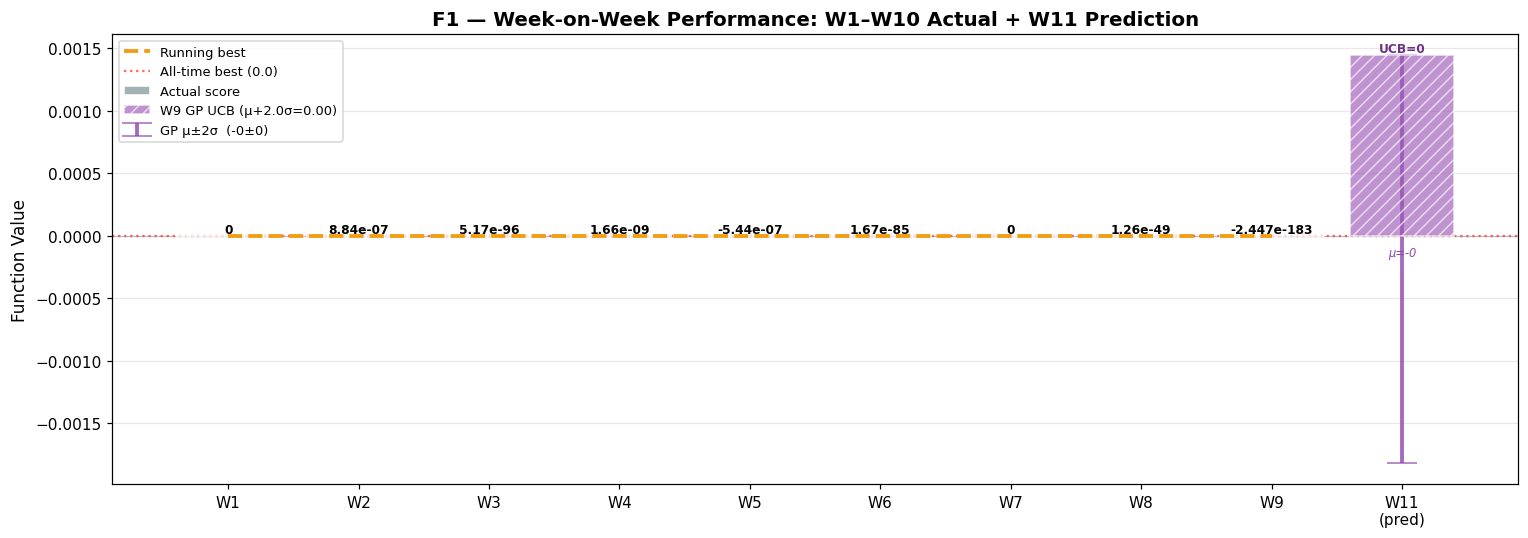

✅ Saved: F1_W11_WeekOnWeek.png
   GP μ=-0.00  σ=0.00  UCB=0.00
   Note: EI selects by improvement potential (μ+σ*ϕ/Φ), not raw μ.
   UCB=0.00 is the GP's optimistic bound and is shown as the W7 bar.


In [23]:
# ══════════════════════════════════════════════════════════════════
# STEP 13B — Week-on-Week Performance Chart
# W1-W9 actual scores + W10 GP prediction
# ══════════════════════════════════════════════════════════════════

week_scores  = [0.0, 8.84e-07, 5.17e-96, 1.66e-09, -5.44e-07, 1.67e-85, 0.0, 1.26e-49, -2.447e-183]   # W1-W9
week_labels  = [f'W{w}' for w in range(1, len(week_scores)+1)] + [f'W{WEEK}\n(pred)']
running_best = []
rb = week_scores[0]
for s in week_scores:
    rb = max(rb, s) if MAXIMIZE else min(rb, s)
    running_best.append(rb)

fig_ww, ax_ww = plt.subplots(figsize=(14, 5))

# Bar colours — green if improvement on prior week, red if regression, grey W1
bar_colors = ['#95a5a6']
for i in range(1, len(week_scores)):
    improved = week_scores[i] > week_scores[i-1] if MAXIMIZE else week_scores[i] < week_scores[i-1]
    bar_colors.append('#2ecc71' if improved else '#e74c3c')

bars = ax_ww.bar(range(len(week_scores)), week_scores,
                 color=bar_colors, edgecolor='white', linewidth=1.2,
                 alpha=0.85, zorder=3, label='Actual score')

# Running best step line
ax_ww.step(range(len(running_best)), running_best,
           where='post', color='#f39c12', linewidth=2.5,
           linestyle='--', label='Running best', zorder=4)

# W7 prediction bar — use UCB as the "optimistic upper bound" prediction
# UCB = mu + kappa*sigma is the correct metric for what the GP believes
# the function could be at this point. sub_mu can be < best_value because
# EI selects on IMPROVEMENT POTENTIAL (exploration), not raw GP mean.
_pred_val   = sub_ucb                          # optimistic prediction
_pred_label = f'W9 GP UCB (μ+{UCB_KAPPA}σ={sub_ucb:.2f})'

ax_ww.bar(len(week_scores), _pred_val,
          color='#9b59b6', edgecolor='white', linewidth=1.2,
          alpha=0.65, hatch='///', zorder=3, label=_pred_label)
ax_ww.errorbar(len(week_scores), sub_mu, yerr=2*sub_sigma,
               fmt='none', color='#8e44ad', capsize=10,
               linewidth=2.5, alpha=0.8, label=f'GP μ±2σ  ({sub_mu:.0f}±{2*sub_sigma:.0f})')

# Mark best_value as a horizontal reference
ax_ww.axhline(best_value, color='red', linewidth=1.5, linestyle=':',
              alpha=0.6, label=f'All-time best ({best_value:.1f})', zorder=2)

# Annotate actual bars
_y_range = max(week_scores) - min(week_scores)
for i, (bar, val) in enumerate(zip(bars, week_scores)):
    ypos = val + _y_range * 0.02
    ax_ww.text(bar.get_x() + bar.get_width()/2, ypos,
               f'{val:.4g}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Annotate prediction bar: show both UCB and mu
ax_ww.text(len(week_scores), _pred_val + _y_range * 0.02,
           f'UCB={sub_ucb:.0f}', ha='center', va='bottom', fontsize=8,
           fontweight='bold', color='#6c3483')
ax_ww.text(len(week_scores), sub_mu - _y_range * 0.06,
           f'μ={sub_mu:.0f}', ha='center', va='bottom', fontsize=7.5,
           color='#8e44ad', style='italic')

ax_ww.set_xticks(range(len(week_labels)))
ax_ww.set_xticklabels(week_labels, fontsize=10)
ax_ww.set_ylabel('Function Value', fontsize=11)
ax_ww.set_title(f'{FUNCTION_ID} — Week-on-Week Performance: W1–W{WEEK-1} Actual + W{WEEK} Prediction',
                fontsize=13, fontweight='bold')
ax_ww.legend(fontsize=8.5, loc='best')
ax_ww.axhline(0, color='gray', linewidth=0.8, alpha=0.4)
ax_ww.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_WeekOnWeek.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_WeekOnWeek.png')
print(f'   GP μ={sub_mu:.2f}  σ={sub_sigma:.2f}  UCB={sub_ucb:.2f}')
print(f'   Note: EI selects by improvement potential (μ+σ*ϕ/Φ), not raw μ.')
print(f'   UCB={sub_ucb:.2f} is the GP\'s optimistic bound and is shown as the W7 bar.')


---
## 📋 STEP 14 — Final Formatted Submission

The winning point formatted as a dash-separated string — ready to copy directly into the BBO submission interface.

Saved as both `.npy` (for reuse in future notebooks) and `.txt` (for submission).

In [24]:
submission = np.clip(submission, 0.0, 1.0)
assert np.all((submission >= 0) & (submission <= 1)), f'Submission out of bounds: {submission}'
submission_str = '-'.join([f'{x:.6f}' for x in submission])

_W = 66
def _row(s=''):
    pad = _W - len(s)
    return f'\u2551  {s}{" " * max(0, pad)}\u2551'

_TOP = '\u2554' + '\u2550' * (_W + 2) + '\u2557'
_MID = '\u2560' + '\u2550' * (_W + 2) + '\u2563'
_BOT = '\u255a' + '\u2550' * (_W + 2) + '\u255d'

if sub_mu > best_value:
    _msg = f'GP PREDICTS NEW BEST: {sub_mu:.4f} > {best_value:.4f}'
elif sub_mu > latest_val:
    _msg = f'GP PREDICTS RECOVERY: {sub_mu:.4f} > {latest_val:.4f}'
else:
    _msg = f'EXPLORING UNCERTAIN REGION  mu={sub_mu:.4f}'

print(_TOP)
print(_row(f'WEEK {WEEK} FINAL SUBMISSION -- {FUNCTION_ID}'))
print(_MID)
print(_row(f'Method     : Adaptive Model (7 types) + GP/EI  MAXIMIZE'))
print(_row(f'Best model : {best_name:<22}  CV = {best_info["mean"]:.1%}'))
print(_row(f'GP R2      : {r2:.4f}'))
print(_MID)
print(_row(f'GP mu      : {sub_mu:.6f}'))
print(_row(f'GP sigma   : {sub_sigma:.6f}'))
print(_row(f'UCB        : {sub_ucb:.6f}'))
print(_row(f'EI         : {sub_ei:.6f}'))
print(_MID)
print(_row(f'All-time best : {best_value:.6f}'))
print(_row(f'Last week     : {latest_val:.6f}'))
print(_row(f'Delta vs best : {sub_mu - best_value:+.6f}'))
print(_MID)
print(_row(_msg))
print(_MID)
print(_row('COPY THIS TO SUBMIT:'))
print(_row())
print(_row(submission_str))
print(_row())
print(_BOT)

np.save(f'{FUNCTION_ID}_W{WEEK}_submission.npy', submission)
with open(f'{FUNCTION_ID}_W{WEEK}_submission.txt', 'w', encoding='utf-8') as f:
    f.write(f'# {FUNCTION_ID} Week {WEEK} | Method: Adaptive+GP/EI | MAXIMIZE\n')
    f.write(f'# Model: {best_name} CV={best_info["mean"]:.1%} | GP R2={r2:.4f}\n')
    f.write(f'# mu={sub_mu:.6f} sigma={sub_sigma:.6f} EI={sub_ei:.6f}\n')
    f.write(f'# best={best_value:.6f} delta={sub_mu-best_value:+.6f}\n')
    f.write(submission_str + '\n')

print(f'\n  {FUNCTION_ID}_W{WEEK}_submission.npy')
print(f'  {FUNCTION_ID}_W{WEEK}_submission.txt')
print()
print('  ALL VISUALISATIONS:')
for _step, _name in [
    ('Step3',  'History'),
    ('Step6',  'ModelPredictions'),
    ('Step7',  'ModelComparison'),
    ('Step11a','GlobalAcquisition'),
    ('Step11b','PerDimAcquisition'),
    ('Step12a','GP_Surfaces'),
    ('Step13', 'Dashboard'),
]:
    print(f'     {FUNCTION_ID}_W{WEEK}_{_step}_{_name}.png')
print()
print('  MAXIMIZATION -- HIGHER IS ALWAYS BETTER')


╔════════════════════════════════════════════════════════════════════╗
║  WEEK 11 FINAL SUBMISSION -- F1                                    ║
╠════════════════════════════════════════════════════════════════════╣
║  Method     : Adaptive Model (7 types) + GP/EI  MAXIMIZE           ║
║  Best model : Random Forest           CV = 79.4%                   ║
║  GP R2      : 1.0000                                               ║
╠════════════════════════════════════════════════════════════════════╣
║  GP mu      : -0.000187                                            ║
║  GP sigma   : 0.000819                                             ║
║  UCB        : 0.001451                                             ║
║  EI         : 0.000000                                             ║
╠════════════════════════════════════════════════════════════════════╣
║  All-time best : 0.000000                                          ║
║  Last week     : 0.000000                                          ║
║  Del

---
## 💾 STEP 15 — Save Hyperparameter Record & Visualisation Index

### Why Keep a Hyperparameter Record?

Each week we tune parameters based on what we've learned. Without a written record it's impossible to:
- Know **why** a particular week performed well or poorly
- Compare parameter choices across weeks systematically
- Reproduce a run that gave a good result
- Build intuition about which settings work for which function types

This step saves a **complete, self-contained record** of everything used in this run:
- All hyperparameter values with their rationale
- GP kernel specification (fitted parameters, not just defaults)
- Model CV results for all 7 classifiers
- Selected model and its performance
- Submission point, predictions, and context
- Index of all visualisation files produced

Saved as: `{FUNCTION_ID}_W{WEEK}_hyperparameters.json` and `{FUNCTION_ID}_W{WEEK}_run_report.txt`

In [25]:
import json as _json
import os
from datetime import datetime

# ── 1. Collect all visualisation files produced ───────────────
viz_files = [
    f'{FUNCTION_ID}_W{WEEK}_Step3_History.png',
    f'{FUNCTION_ID}_W{WEEK}_Step6_ModelPredictions.png',
    f'{FUNCTION_ID}_W{WEEK}_Step7_ModelComparison.png',
    f'{FUNCTION_ID}_W{WEEK}_Step11a_GlobalAcquisition.png',
    f'{FUNCTION_ID}_W{WEEK}_Step11b_EI_PerDimension.png',
    f'{FUNCTION_ID}_W{WEEK}_Step11c_UCB_PerDimension.png',
    f'{FUNCTION_ID}_W{WEEK}_Step12_AcquisitionSurface.png',
    f'{FUNCTION_ID}_W{WEEK}_Step13_Dashboard.png',
]
viz_status = {f: os.path.exists(f) for f in viz_files}

# ── 2. GP kernel details ──────────────────────────────────────
kernel_str  = str(gp.kernel_)
kernel_init = str(gp.kernel)
gp_params   = gp.kernel_.get_params()
# Extract fitted length scale and amplitude cleanly
gp_param_clean = {k: float(v) if hasattr(v, '__float__') else str(v)
                  for k, v in gp_params.items()}

# ── 3. Model CV results ───────────────────────────────────────
model_records = {}
for name, info in cv_results.items():
    model_records[name] = {
        'cv_mean'   : round(float(info['mean']), 6),
        'cv_std'    : round(float(info['std']),  6),
        'cv_folds'  : [round(float(s), 6) for s in info['scores']],
        'selected'  : name == best_name,
        'type'      : 'neural_network' if 'NN' in name else 'classical',
    }

# ── 4. Dimension analysis ─────────────────────────────────────
dim_records = {}
for d in range(n_dims):
    ei_peak_val  = float(sweep_vals[int(np.argmax(dim_ei_curves[d]))])
    ucb_peak_val = float(sweep_vals[int(np.argmax(dim_ucb_curves[d]))])
    dim_records[f'X{d+1}'] = {
        'best_point_value' : round(float(best_point[d]), 6),
        'submission_value' : round(float(submission[d]), 6),
        'gp_sensitivity'   : round(float(sensitivities[d]), 6),
        'ei_peak_at'       : round(ei_peak_val, 6),
        'ucb_peak_at'      : round(ucb_peak_val, 6),
        'ei_ucb_agree'     : abs(ei_peak_val - ucb_peak_val) < 0.1,
    }

# ── 5. Build full hyperparameter record ──────────────────────
record = {
    'meta': {
        'function_id'   : FUNCTION_ID,
        'week'          : WEEK,
        'timestamp'     : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'input_file'    : INPUT_FILE,
        'output_file'   : OUTPUT_FILE,
        'objective'     : 'MAXIMIZE',
    },
    'data': {
        'n_samples'     : int(n_samples),
        'n_dims'        : int(n_dims),
        'np_ratio'      : round(float(n_samples / n_dims), 4),
        'y_min'         : round(float(y_train.min()), 8),
        'y_max'         : round(float(y_train.max()), 8),
        'y_mean'        : round(float(y_train.mean()), 8),
        'y_std'         : round(float(y_train.std()),  8),
        'best_value'    : round(float(best_value),     8),
        'best_idx'      : int(best_idx),
        'best_point'    : [round(float(v), 8) for v in best_point],
        'latest_value'  : round(float(latest_val),    8),
    },
    'hyperparameters': {
        'TOP_PERCENTILE': {
            'value'    : TOP_PERCENTILE,
            'purpose'  : 'Fraction of samples labelled class 1. Top X% = HIGH values = GOOD.',
            'rationale': f'Top {TOP_PERCENTILE}% gives {n_pos} positive samples. '
                          f'Balances selectivity vs having enough training signal.'
        },
        'N_CANDIDATES': {
            'value'    : N_CANDIDATES,
            'purpose'  : 'Total candidate pool size evaluated by classifier+GP before selecting 1 to submit.',
            'rationale': f'{N_CANDIDATES:,} provides dense coverage in {n_dims}D space. '
                          f'Larger = better coverage but slower GP.'
        },
        'EXPLOIT_RATIO': {
            'value'    : EXPLOIT_RATIO,
            'purpose'  : 'Fraction of candidates sampled near best-known point (exploitation) vs random (exploration).',
            'rationale': f'{int(EXPLOIT_RATIO*100)}% exploitation justified at Week {WEEK} — strong best point established. '
                          f'Early weeks: 0.6-0.7. Later weeks: 0.8-0.9.'
        },
        'EXPLOIT_SIGMA': {
            'value'    : EXPLOIT_SIGMA,
            'purpose'  : 'Gaussian std dev for exploitation sampling around best point.',
            'rationale': f'sigma={EXPLOIT_SIGMA} in [0,1]^{n_dims} creates ±{2*EXPLOIT_SIGMA:.2f} search radius. '
                          f'Tight enough to stay near best, loose enough to find local improvements.'
        },
        'UCB_KAPPA': {
            'value'    : UCB_KAPPA,
            'purpose'  : 'Exploration weight in UCB = mu + kappa*sigma. Higher = more exploratory.',
            'rationale': f'kappa={UCB_KAPPA} ~ 95% CI. Standard choice for Week {WEEK}. '
                          f'Use 3-5 early in search, 1-2 when exploiting known best region.'
        },
        'EI_XI': {
            'value'    : EI_XI,
            'purpose'  : 'Exploration jitter in EI. EI = (mu - y_best - xi)*Phi(Z) + sigma*phi(Z).',
            'rationale': f'xi={EI_XI} prevents EI from over-committing to tiny improvements near best. '
                          f'Small value: slight nudge toward exploration.'
        },
        'GP_RESTARTS': {
            'value'    : GP_RESTARTS,
            'purpose'  : 'Random restarts for GP kernel hyperparameter optimisation.',
            'rationale': f'{GP_RESTARTS} restarts balances fit quality vs runtime. '
                          f'Use 10+ for final weeks when GP quality is critical.'
        },
        'FILTER_PERCENTILE': {
            'value'    : FILTER_PERCENTILE,
            'purpose'  : 'Discard bottom X% of candidates by classifier P(class=1) before GP.',
            'rationale': f'Keeps {int(N_CANDIDATES*(1-FILTER_PERCENTILE/100)):,} of {N_CANDIDATES:,} for GP. '
                          f'Removes clearly bad regions efficiently.'
        },
        'NN_ARCHITECTURES': {
            'small'    : list(NN_SMALL),
            'medium'   : list(NN_MEDIUM),
            'large'    : list(NN_LARGE),
            'purpose'  : 'Three NN sizes tested to match function landscape complexity.',
            'rationale': 'Small=simple/linear landscapes. Medium=general purpose. '
                          'Large=highly non-linear. Early stopping prevents overfitting.'
        },
    },
    'gp_kernel': {
        'type'          : 'ConstantKernel * Matern(nu=2.5)',
        'nu'            : 2.5,
        'initial_spec'  : kernel_init,
        'fitted_spec'   : kernel_str,
        'fitted_params' : gp_param_clean,
        'normalize_y'   : True,
        'alpha_nugget'  : 1e-6,
        'n_restarts'    : GP_RESTARTS,
        'train_r2'      : round(float(r2), 6),
        'train_rmse'    : round(float(rmse), 8),
        'rationale'     : 'Matern 5/2 is robust for BBO: allows sharp transitions, '
                           'assumes twice-differentiable function. ConstantKernel scales amplitude. '
                           'normalize_y stabilises fitting when y range is large.'
    },
    'classification': {
        'n_cv_folds'         : int(n_cv_folds),
        'label_threshold'    : round(float(threshold), 8),
        'n_positive_class1'  : int(n_pos),
        'n_negative_class0'  : int(n_samples - n_pos),
        'selected_model'     : best_name,
        'selected_cv_mean'   : round(float(best_info['mean']), 6),
        'selected_cv_std'    : round(float(best_info['std']),  6),
        'all_model_results'  : model_records,
    },
    'candidates': {
        'total_generated'  : int(N_CANDIDATES),
        'n_exploit'        : int(int(N_CANDIDATES * EXPLOIT_RATIO)),
        'n_explore'        : int(N_CANDIDATES - int(N_CANDIDATES * EXPLOIT_RATIO)),
        'after_filter'     : int(len(X_filt)),
        'filter_model'     : best_name,
    },
    'acquisition': {
        'method'               : 'Expected Improvement (primary) + UCB (reference)',
        'ei_formula'           : 'EI(x) = (mu - y_best - xi)*Phi(Z) + sigma*phi(Z), Z=(mu-y_best-xi)/sigma',
        'ucb_formula'          : f'UCB(x) = mu + {UCB_KAPPA}*sigma',
        'direction'            : 'MAXIMIZE — argmax EI',
        'ei_max'               : round(float(EI_acq.max()), 8),
        'ucb_max'              : round(float(UCB_acq.max()), 8),
        'pct_positive_ei'      : round(float(100*np.mean(EI_acq>0)), 2),
    },
    'submission': {
        'point'            : [round(float(v), 8) for v in submission],
        'formatted_string' : submission_str,
        'gp_mu'            : round(float(sub_mu),    8),
        'gp_sigma'         : round(float(sub_sigma), 8),
        'ei'               : round(float(sub_ei),    8),
        'ucb'              : round(float(sub_ucb),   8),
        'exploit_term'     : round(float(sub_exp),   8),
        'explore_term'     : round(float(sub_expl),  8),
        'ei_driver'        : 'exploitation' if sub_exp > sub_expl else 'exploration',
        'delta_vs_best'    : round(float(sub_mu - best_value), 8),
        'prediction'       : 'new_best' if sub_mu > best_value else
                              'recovery' if sub_mu > latest_val else 'exploration',
    },
    'dimensions': dim_records,
    'visualisations': {
        f: {'exists': viz_status[f], 'description': desc}
        for f, desc in zip(viz_files, [
            'Historical performance: all evaluations, running best, value distribution',
            'All 7 model P(class=1) prediction distributions + agreement correlation matrix',
            'CV accuracy bar chart + per-fold accuracy lines for all 7 models',
            'Global EI acquisition curve (log) and UCB acquisition curve (sorted)',
            'EI acquisition curve per dimension — sweeping each dim 0→1',
            'UCB acquisition curve per dimension — sweeping each dim 0→1',
            'GP mean, EI, UCB contour surfaces on top-2 sensitive dimensions',
            'Full submission dashboard: history, coordinates, EI decomp, summary table',
        ])
    },
}

# ── 6. Save JSON ──────────────────────────────────────────────
json_fname = f'{FUNCTION_ID}_W{WEEK}_hyperparameters.json'
with open(json_fname, 'w', encoding='utf-8') as fp:
    _json.dump(record, fp, indent=2)
print(f'✅ Saved JSON : {json_fname}')

# ── 7. Save human-readable text report ───────────────────────
txt_fname = f'{FUNCTION_ID}_W{WEEK}_run_report.txt'
with open(txt_fname, 'w', encoding='utf-8') as fp:
    def w(s=''): fp.write(s + '\n')
    w('=' * 70)
    w(f'  BBO RUN REPORT — {FUNCTION_ID}  Week {WEEK}')
    w(f'  Generated : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
    w('=' * 70)
    w()
    w('── DATA ────────────────────────────────────────────────────────────')
    w(f'  Function    : {FUNCTION_ID}')
    w(f'  Week        : {WEEK}')
    w(f'  Samples     : {n_samples}  |  Dims: {n_dims}D  |  n/p: {n_samples/n_dims:.2f}')
    w(f'  Y range     : [{y_train.min():.6f}, {y_train.max():.6f}]')
    w(f'  All-time best: {best_value:.8f}  @ index {best_idx}')
    w(f'  Best point  : {best_point}')
    w(f'  Last week   : {latest_val:.8f}')
    w()
    w('── HYPERPARAMETERS ─────────────────────────────────────────────────')
    w(f'  TOP_PERCENTILE    = {TOP_PERCENTILE}%')
    w(f'  N_CANDIDATES      = {N_CANDIDATES:,}')
    w(f'  EXPLOIT_RATIO     = {EXPLOIT_RATIO}  ({int(EXPLOIT_RATIO*100)}% near best, {int((1-EXPLOIT_RATIO)*100)}% random)')
    w(f'  EXPLOIT_SIGMA     = {EXPLOIT_SIGMA}')
    w(f'  UCB_KAPPA         = {UCB_KAPPA}  (UCB = mu + {UCB_KAPPA}*sigma)')
    w(f'  EI_XI             = {EI_XI}')
    w(f'  GP_RESTARTS       = {GP_RESTARTS}')
    w(f'  FILTER_PERCENTILE = {FILTER_PERCENTILE}%  (keep top {100-FILTER_PERCENTILE}%)')
    w(f'  RANDOM_SEED       = {RANDOM_SEED}')
    w(f'  NN_SMALL          = {NN_SMALL}')
    w(f'  NN_MEDIUM         = {NN_MEDIUM}')
    w(f'  NN_LARGE          = {NN_LARGE}')
    w()
    w('── GP KERNEL ───────────────────────────────────────────────────────')
    w(f'  Type            : ConstantKernel * Matern(nu=2.5)')
    w(f'  Initial spec    : {kernel_init}')
    w(f'  Fitted spec     : {kernel_str}')
    w(f'  normalize_y     : True')
    w(f'  alpha (nugget)  : 1e-6')
    w(f'  n_restarts      : {GP_RESTARTS}')
    w(f'  Training R²     : {r2:.6f}')
    w(f'  Training RMSE   : {rmse:.8f}')
    w(f'  Fitted params   :')
    for k, v in gp_param_clean.items():
        w(f'    {k}: {v}')
    w()
    w('── CLASSIFICATION ──────────────────────────────────────────────────')
    w(f'  Label threshold : {threshold:.8f}  (top {TOP_PERCENTILE}%)')
    w(f'  Class 1 (HIGH)  : {n_pos} samples')
    w(f'  Class 0 (LOW)   : {n_samples - n_pos} samples')
    w(f'  CV folds        : {n_cv_folds}')
    w()
    w(f'  All model results ({n_cv_folds}-fold CV):')
    w(f'  {"Model":<30}  {"CV Mean":>9}  {"CV Std":>8}  Selected')
    w('  ' + '-'*58)
    for name, res in sorted(model_records.items(), key=lambda x: -x[1]['cv_mean']):
        sel = '★ SELECTED' if res['selected'] else ''
        w(f'  {name:<30}  {res["cv_mean"]:>9.4f}  {res["cv_std"]:>8.4f}  {sel}')
    w()
    w('── ACQUISITION ─────────────────────────────────────────────────────')
    w(f'  Method    : EI (primary) + UCB (reference)')
    w(f'  EI formula: (mu - y_best - xi)*Phi(Z) + sigma*phi(Z)')
    w(f'  UCB formula: mu + {UCB_KAPPA}*sigma')
    w(f'  Direction : MAXIMIZE — argmax')
    w(f'  EI max    : {EI_acq.max():.8f}')
    w(f'  UCB max   : {UCB_acq.max():.8f}')
    w(f'  % EI > 0  : {100*np.mean(EI_acq>0):.1f}%')
    w()
    w('── PER-DIMENSION ANALYSIS ──────────────────────────────────────────')
    w(f'  {"Dim":<6} {"Best":>8} {"Submit":>8} {"Sensitivity":>13} {"EI peak":>9} {"UCB peak":>9} {"Agree"}')
    w('  ' + '-'*66)
    for d in range(n_dims):
        ei_pk  = float(sweep_vals[int(np.argmax(dim_ei_curves[d]))])
        ucb_pk = float(sweep_vals[int(np.argmax(dim_ucb_curves[d]))])
        agree  = 'YES' if abs(ei_pk - ucb_pk) < 0.1 else 'NO'
        w(f'  X{d+1:<5} {best_point[d]:>8.4f} {submission[d]:>8.4f} {sensitivities[d]:>13.6f} {ei_pk:>9.4f} {ucb_pk:>9.4f} {agree}')
    w()
    w('── SUBMISSION ──────────────────────────────────────────────────────')
    w(f'  Point     : {submission}')
    w(f'  GP mu     : {sub_mu:.8f}')
    w(f'  GP sigma  : {sub_sigma:.8f}')
    w(f'  EI        : {sub_ei:.8f}')
    w(f'  UCB       : {sub_ucb:.8f}')
    w(f'  EI driver : {"exploitation" if sub_exp > sub_expl else "exploration"}')
    w(f'  Delta vs best: {sub_mu - best_value:+.8f}')
    w(f'  Prediction: {"NEW BEST" if sub_mu > best_value else "RECOVERY" if sub_mu > latest_val else "EXPLORATION"}')
    w()
    w(f'  FORMATTED STRING:')
    w(f'  {submission_str}')
    w()
    w('── VISUALISATIONS PRODUCED ─────────────────────────────────────────')
    for fname, info in record['visualisations'].items():
        status = '✅' if info['exists'] else '⚠️ (not yet saved)'
        w(f'  {status}  {fname}')
        w(f'       {info["description"]}')
    w()
    w('=' * 70)
    w(f'  END OF REPORT — {FUNCTION_ID} Week {WEEK}')
    w('=' * 70)

print(f'✅ Saved report: {txt_fname}')
print()

# ── 8. Print summary of what was saved ───────────────────────
W2 = 64
def _r2(text): return f'\u2551 {text.ljust(W2-2)} \u2551'
def _d2():     return '\u2560' + '\u2550'*W2 + '\u2563'
print('\u2554' + '\u2550'*W2 + '\u2557')
print(_r2(f'WEEK {WEEK} RUN COMPLETE -- {FUNCTION_ID}  |  Mike Kennelly'))
print(_d2())
print(_r2(f'VISUALISATIONS ({len(viz_files)} files):'))
for fname in viz_files:
    status = 'OK' if viz_status[fname] else 'MISSING'
    short  = fname.split('_', 3)[-1].replace('.png','')
    print(_r2(f'  [{status}] {short}'))
print(_d2())
print(_r2('SAVED FILES:'))
print(_r2(f'  {FUNCTION_ID}_W{WEEK}_submission.npy'))
print(_r2(f'  {FUNCTION_ID}_W{WEEK}_submission.txt'))
print(_r2(f'  {json_fname}'))
print(_r2(f'  {txt_fname}'))
print(_d2())
print(_r2('SUBMISSION STRING:'))
print(_r2(f'  {submission_str}'))
print('\u255a' + '\u2550'*W2 + '\u255d')
print()
print('  MAXIMIZATION -- HIGHER IS ALWAYS BETTER')


✅ Saved JSON : F1_W11_hyperparameters.json
✅ Saved report: F1_W11_run_report.txt

╔════════════════════════════════════════════════════════════════╗
║ WEEK 11 RUN COMPLETE -- F1  |  Mike Kennelly                   ║
╠════════════════════════════════════════════════════════════════╣
║ VISUALISATIONS (8 files):                                      ║
║   [OK] History                                                 ║
║   [OK] ModelPredictions                                        ║
║   [OK] ModelComparison                                         ║
║   [OK] GlobalAcquisition                                       ║
║   [OK] EI_PerDimension                                         ║
║   [OK] UCB_PerDimension                                        ║
║   [MISSING] AcquisitionSurface                                 ║
║   [OK] Dashboard                                               ║
╠════════════════════════════════════════════════════════════════╣
║ SAVED FILES:                                 